# Preprocess ECG PVC: Visual Segmentasi Lead

Notebook ini dibuat lebih sederhana untuk validasi visual. Fokusnya hanya sampai segmentasi sinyal per lead:

- baca `ecg-raw*`
- resize ke ukuran standar
- tampilkan box crop dan hasil crop
- split kiri/kanan
- estimasi baseline 12 lead
- buat box awal per lead
- ekspansi tinggi box secara dinamis memakai Otsu dan satu sinyal utama
- gunakan main signal sebagai mask utama tanpa thinning
- tempel ulang mask sinyal ke gambar crop dan ECG raw resized
- rekonstruksi lead ke tinggi 640, deteksi R-peak, dan potong siklus untuk input YOLO

Tidak ada slider koordinat dan tidak ada tabel output panjang.


## 1. Konfigurasi

Ubah `PATIENT_ID` untuk memvalidasi pasien lain. Untuk crop awal, ubah `REFERENCE_CROP_BOX` dalam koordinat raw referensi `1085x767`; notebook akan otomatis menghitung ulang `CROP_BOX` yang dipakai setelah resize ke ukuran standar.


In [619]:
from __future__ import annotations

import json
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display
from PIL import Image, ImageDraw, ImageOps

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebook-preprocess" else Path.cwd()
VALID_PATIENT_DIR = PROJECT_ROOT / "data" / "patient" / "valid"
CONFIG_PATH = VALID_PATIENT_DIR / "ecg_pvc_crop_config.json"

PATIENT_ID = "P-00007"

# Canvas raw referensi yang dulu dipakai untuk menentukan crop.
# Semua image pasien tetap di-resize ke ukuran standar kecil dari canvas ini.
REFERENCE_SIZE = (1085, 767)
TARGET_STANDARD_WIDTH = 384

# Ubah box ini jika ingin adjust manual dari koordinat raw/reference.
# REFERENCE_CROP_BOX = {"x1": 17, "y1": 143, "x2": 1065, "y2": 675} # p-0001
# REFERENCE_CROP_BOX = {"x1": 30, "y1": 120, "x2": 1040, "y2": 680} # p-00007

# Opsional: adjust crop per pasien di koordinat raw/reference 1085x767.
# Jika pasien tidak ada di dict ini, notebook memakai REFERENCE_CROP_BOX.
PATIENT_REFERENCE_CROP_BOXES = {
    "P-00001": {"x1": 17, "y1": 143, "x2": 1065, "y2": 675},
    "P-00002": {"x1": 20, "y1": 135, "x2": 1070, "y2": 685},
    "P-00007": {"x1": 30, "y1": 150, "x2": 1040, "y2": 680},
    "P-00015": {"x1": 45, "y1": 138, "x2": 1070, "y2": 694},
}

LEADS_PER_HALF = 6
LEFT_LEAD_LABELS = ["I", "II", "III", "aVR", "aVL", "aVF"]
RIGHT_LEAD_LABELS = ["V1", "V2", "V3", "V4", "V5", "V6"]
LEAD_COLORS = {
    "I": (230, 25, 75),
    "II": (60, 60, 60),
    "III": (30, 80, 220),
    "aVR": (245, 170, 20),
    "aVL": (0, 170, 200),
    "aVF": (240, 40, 190),
    "V1": (160, 60, 60),
    "V2": (40, 150, 65),
    "V3": (40, 60, 170),
    "V4": (120, 100, 30),
    "V5": (20, 125, 145),
    "V6": (170, 55, 150),
}

LEFT_SIGNAL_MARGIN = 26
RIGHT_SIGNAL_MARGIN = 20
EDGE_MARGIN = 6
BAND_VERTICAL_MARGIN = 2
BASELINE_THRESHOLD = 170
BASELINE_SMOOTH_KERNEL = 7

INITIAL_LEAD_HALF_HEIGHT = 12
EXPAND_STEP = 2
MAX_EXPAND_ITER = 80
MAX_VERTICAL_EXTRA = 28
NEIGHBOR_BASELINE_GUARD = 2
TOUCH_MARGIN = 1
MIN_LEAD_HEIGHT = 24

# Kernel blur sebelum Otsu. (1, 1) berarti tanpa smoothing agar detail sinyal tidak terlalu hilang.
OTSU_BLUR_KERNEL = (3, 3)
OTSU_SIGNAL_OFFSET = 4
SIGNAL_THRESHOLD_MIN = 120
SIGNAL_THRESHOLD_MAX = 220
CONNECTED_MIN_AREA = 3
CONNECTED_MIN_WIDTH = 2
CONNECTED_MIN_HEIGHT = 2
BASELINE_NEAR_MARGIN = 5
COMPONENT_MAX_GAP_TO_BASELINE = 8
MAIN_SIGNAL_BRIDGE_KERNEL = (7, 3)
MAIN_SIGNAL_MIN_SPAN_RATIO = 0.45
MAIN_SIGNAL_EDGE_MARGIN = 4
MAIN_SIGNAL_REPAIR_MAX_GAP = 18

RECONSTRUCTED_LEAD_HEIGHT = 640
YOLO_INPUT_SIZE = 640
RPEAK_MIN_DISTANCE_RATIO = 0.12
RPEAK_MIN_ABS_AMPLITUDE = 55
RPEAK_RELATIVE_THRESHOLD = 0.45
RPEAK_PERCENTILE_THRESHOLD = 90
RPEAK_SMOOTH_KERNEL = 9
CYCLE_LEFT_RR_RATIO = 0.45
CYCLE_RIGHT_RR_RATIO = 0.55
MIN_CYCLE_WIDTH = 120
MAX_CYCLES_PER_LEAD = 8
SIGNAL_ONLY_DARK_THRESHOLD = 230
SIGNAL_ONLY_MASK_DILATE_KERNEL = (3, 3)

OUTPUT_DIR = VALID_PATIENT_DIR / PATIENT_ID / "ecg" / "segmentation-validation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root : {PROJECT_ROOT}")
print(f"Patient      : {PATIENT_ID}")
print(f"Output       : {OUTPUT_DIR}")


Project root : /home/nugee/code-program/code-thesis/thesis-severity
Patient      : P-00007
Output       : /home/nugee/code-program/code-thesis/thesis-severity/data/patient/valid/P-00007/ecg/segmentation-validation


## 2. Helper load ECG dan crop otomatis dari koordinat raw

Cell ini mengambil `ecg-raw*`, resize ke ukuran standar kecil, lalu menghitung `CROP_BOX` dari `REFERENCE_CROP_BOX`. Nilai `crop_box_scaled` di JSON tidak lagi mengunci crop manual.


In [620]:
def calculate_standard_size() -> tuple[int, int]:
    if CONFIG_PATH.exists():
        config = json.loads(CONFIG_PATH.read_text())
        if "standard_size" in config:
            return (int(config["standard_size"]["width"]), int(config["standard_size"]["height"]))

    scale = TARGET_STANDARD_WIDTH / REFERENCE_SIZE[0]
    return (TARGET_STANDARD_WIDTH, round(REFERENCE_SIZE[1] * scale))


def validate_box(box: dict[str, int]) -> dict[str, int]:
    required = {"x1", "y1", "x2", "y2"}
    missing = required - set(box)
    if missing:
        raise ValueError(f"Crop box kurang key: {sorted(missing)}")

    clean_box = {key: int(round(box[key])) for key in ("x1", "y1", "x2", "y2")}
    if clean_box["x1"] >= clean_box["x2"] or clean_box["y1"] >= clean_box["y2"]:
        raise ValueError(f"Crop box tidak valid: {clean_box}")
    return clean_box


def scale_crop_box(
    box: dict[str, int],
    source_size: tuple[int, int],
    target_size: tuple[int, int],
) -> dict[str, int]:
    box = validate_box(box)
    source_w, source_h = source_size
    target_w, target_h = target_size
    scale_x = target_w / source_w
    scale_y = target_h / source_h
    scaled = {
        "x1": round(box["x1"] * scale_x),
        "y1": round(box["y1"] * scale_y),
        "x2": round(box["x2"] * scale_x),
        "y2": round(box["y2"] * scale_y),
    }
    scaled["x1"] = max(0, min(target_w - 1, scaled["x1"]))
    scaled["y1"] = max(0, min(target_h - 1, scaled["y1"]))
    scaled["x2"] = max(scaled["x1"] + 1, min(target_w, scaled["x2"]))
    scaled["y2"] = max(scaled["y1"] + 1, min(target_h, scaled["y2"]))
    return scaled


def reference_crop_box_for_patient(patient_id: str) -> dict[str, int]:
    return validate_box(PATIENT_REFERENCE_CROP_BOXES.get(patient_id, REFERENCE_CROP_BOX))


def crop_box_for_patient(patient_id: str) -> dict[str, int]:
    return scale_crop_box(reference_crop_box_for_patient(patient_id), REFERENCE_SIZE, STANDARD_SIZE)


def box_from_standard_to_raw(box: dict[str, int | float], raw_size: tuple[int, int]) -> dict[str, int]:
    raw_w, raw_h = raw_size
    scale_x = raw_w / STANDARD_SIZE[0]
    scale_y = raw_h / STANDARD_SIZE[1]
    return {
        "x1": int(round(float(box["x1"]) * scale_x)),
        "y1": int(round(float(box["y1"]) * scale_y)),
        "x2": int(round(float(box["x2"]) * scale_x)),
        "y2": int(round(float(box["y2"]) * scale_y)),
    }


def active_crop_box_raw() -> dict[str, int]:
    return box_from_standard_to_raw(CROP_BOX, raw_image.size)


def raw_ecg_path(patient_id: str) -> Path:
    candidates = sorted((VALID_PATIENT_DIR / patient_id / "ecg").glob("ecg-raw*"))
    if not candidates:
        raise FileNotFoundError(f"Tidak ada file ecg-raw* untuk {patient_id}")
    return candidates[0]


def load_raw_image(patient_id: str) -> Image.Image:
    return ImageOps.exif_transpose(Image.open(raw_ecg_path(patient_id))).convert("RGB")


def standardize_image(image: Image.Image) -> Image.Image:
    return image.resize(STANDARD_SIZE, Image.Resampling.LANCZOS)


def crop_pvc_area(standardized_image: Image.Image) -> Image.Image:
    return standardized_image.crop((CROP_BOX["x1"], CROP_BOX["y1"], CROP_BOX["x2"], CROP_BOX["y2"]))


def save_fig(fig, name: str) -> Path:
    path = OUTPUT_DIR / name
    fig.savefig(path, dpi=180, bbox_inches="tight")
    plt.close(fig)
    try:
        with Image.open(path) as saved_image:
            display(saved_image.copy())
    except Exception as error:
        print(f"Visual tersimpan tetapi tidak bisa ditampilkan otomatis: {path} ({error})")
    return path


STANDARD_SIZE = calculate_standard_size()
CROP_BOX = crop_box_for_patient(PATIENT_ID)
raw_image = load_raw_image(PATIENT_ID)
standardized_image = standardize_image(raw_image)
crop_image = crop_pvc_area(standardized_image)

scale_x = STANDARD_SIZE[0] / REFERENCE_SIZE[0]
scale_y = STANDARD_SIZE[1] / REFERENCE_SIZE[1]
print(f"Raw size           : {raw_image.size}")
print(f"Reference size     : {REFERENCE_SIZE}")
print(f"Standardized size  : {standardized_image.size}")
print(f"Scale ref->standard: x={scale_x:.6f}, y={scale_y:.6f}")
print(f"Reference crop box : {reference_crop_box_for_patient(PATIENT_ID)}")
print(f"Crop box used      : {CROP_BOX}")
print(f"Crop box raw image : {active_crop_box_raw()}")
print(f"Crop size          : {crop_image.size}")


Raw size           : (828, 562)
Reference size     : (1085, 767)
Standardized size  : (384, 271)
Scale ref->standard: x=0.353917, y=0.353325
Reference crop box : {'x1': 30, 'y1': 150, 'x2': 1040, 'y2': 680}
Crop box used      : {'x1': 11, 'y1': 53, 'x2': 368, 'y2': 240}
Crop box raw image : {'x1': 24, 'y1': 110, 'x2': 794, 'y2': 498}
Crop size          : (357, 187)


## 3. Visual raw, box crop, dan hasil crop

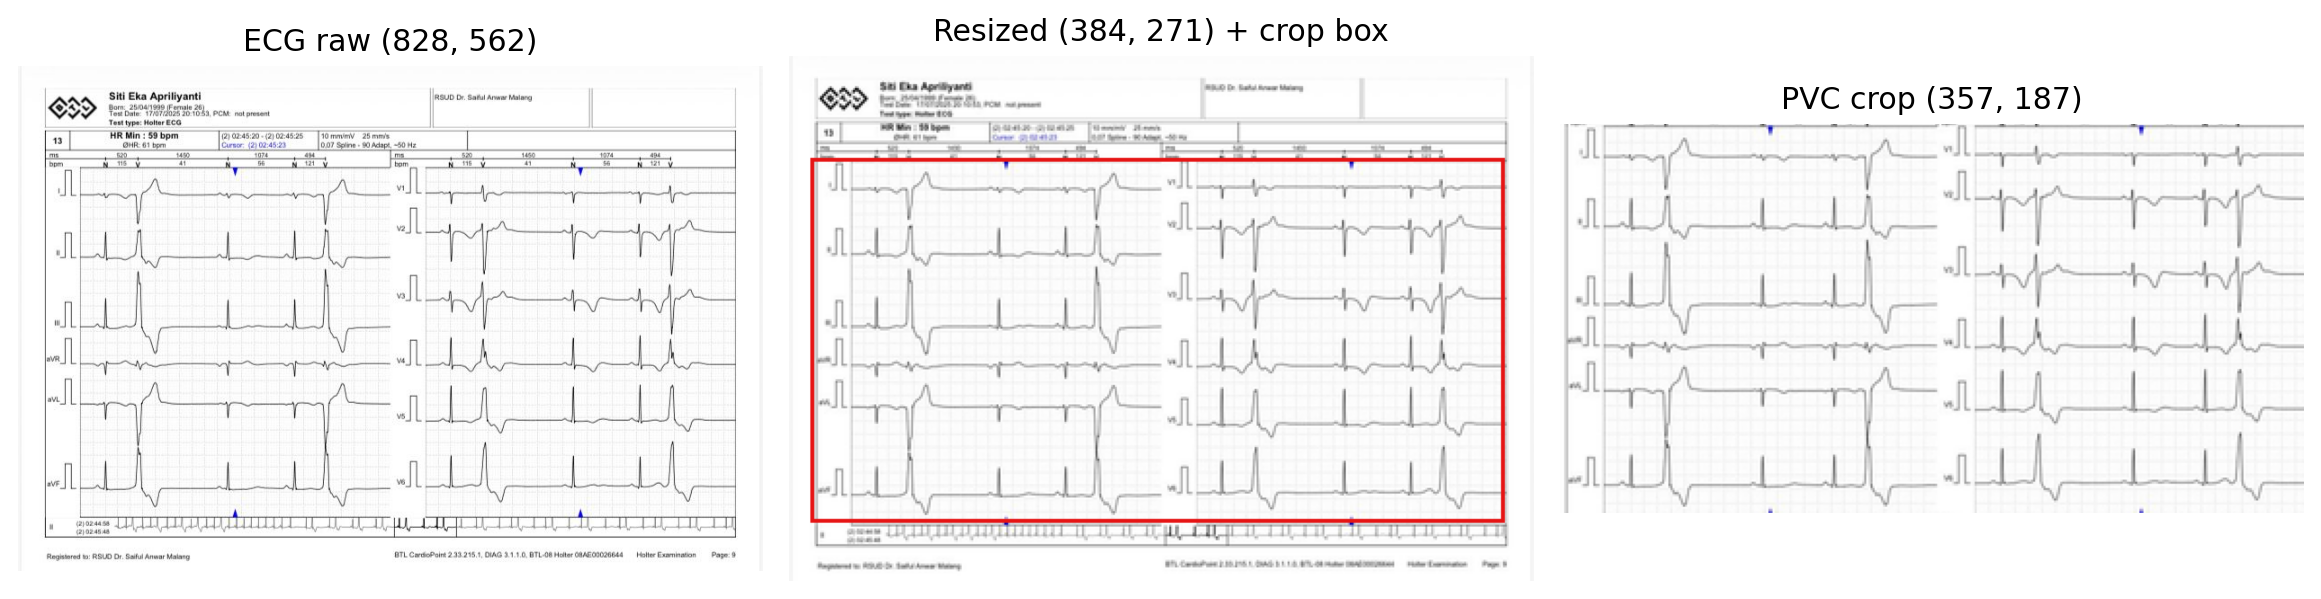

PosixPath('/home/nugee/code-program/code-thesis/thesis-severity/data/patient/valid/P-00007/ecg/segmentation-validation/01_raw_crop_box_result.png')

In [621]:
def visualize_raw_crop() -> Path:
    crop_overlay = standardized_image.copy()
    draw = ImageDraw.Draw(crop_overlay)
    box = (CROP_BOX["x1"], CROP_BOX["y1"], CROP_BOX["x2"], CROP_BOX["y2"])
    draw.rectangle(box, outline=(230, 20, 20), width=2)

    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    axes[0].imshow(raw_image)
    axes[0].set_title(f"ECG raw {raw_image.size}")
    axes[0].axis("off")

    axes[1].imshow(crop_overlay)
    axes[1].set_title(f"Resized {STANDARD_SIZE} + crop box")
    axes[1].axis("off")

    axes[2].imshow(crop_image)
    axes[2].set_title(f"PVC crop {crop_image.size}")
    axes[2].axis("off")

    fig.tight_layout()
    return save_fig(fig, "01_raw_crop_box_result.png")


visualize_raw_crop()

## 4. Split kiri-kanan dan estimasi baseline

Baseline dihitung tanpa model memakai proyeksi horizontal pixel gelap pada setiap band lead.

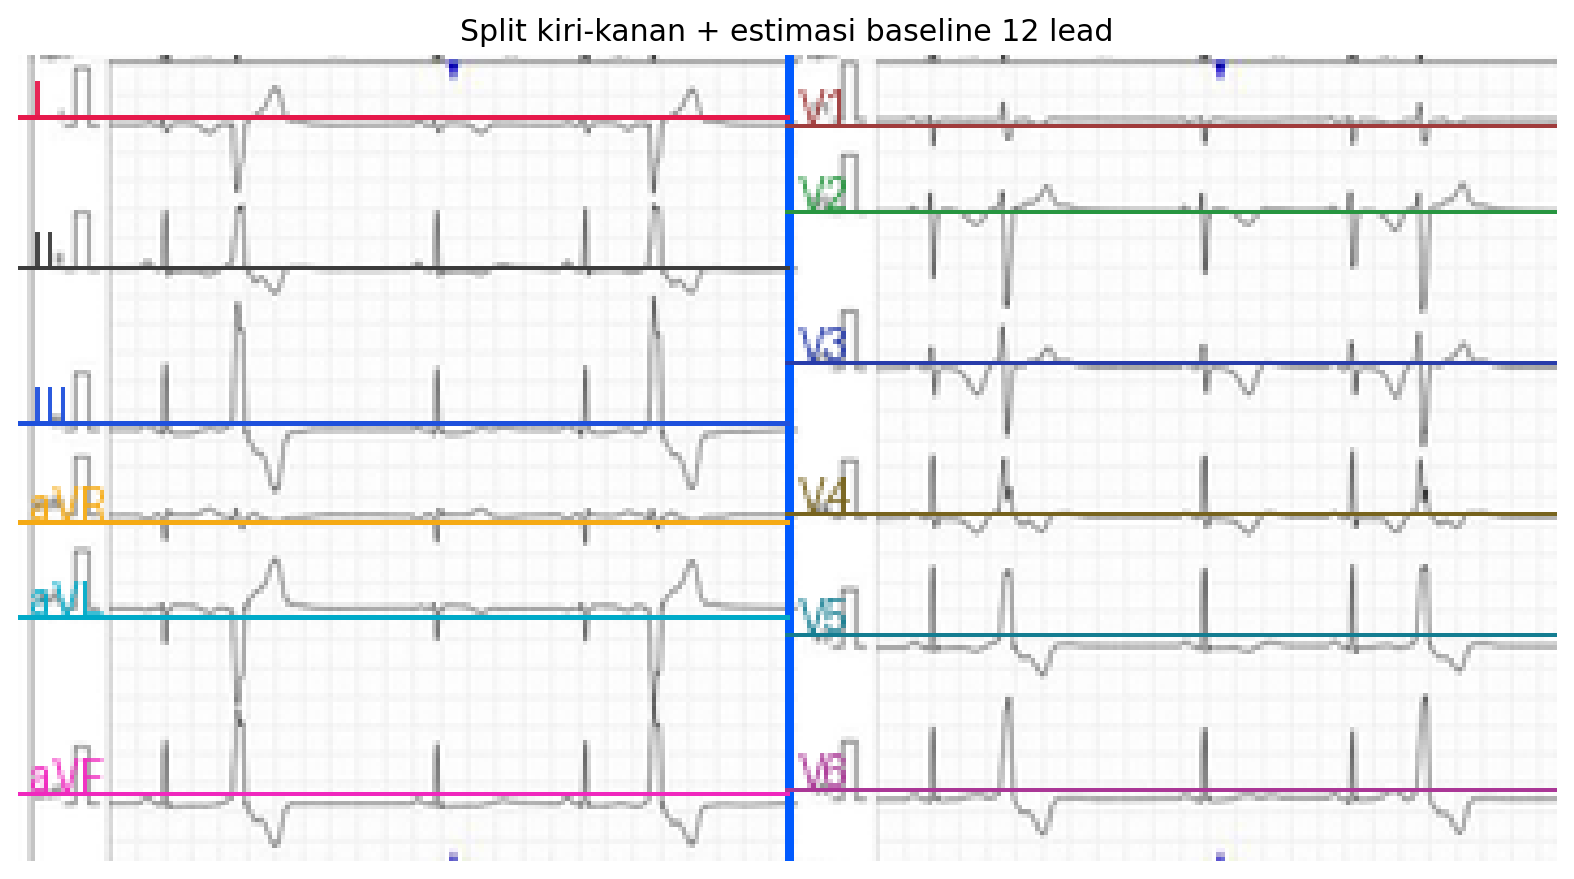

PosixPath('/home/nugee/code-program/code-thesis/thesis-severity/data/patient/valid/P-00007/ecg/segmentation-validation/02_split_baseline.png')

In [622]:
def smooth_1d(values: np.ndarray, kernel_size: int = BASELINE_SMOOTH_KERNEL) -> np.ndarray:
    kernel = np.ones(kernel_size, dtype=float) / kernel_size
    return np.convolve(values.astype(float), kernel, mode="same")


def estimate_baseline_in_band(
    gray_half: np.ndarray,
    y0: int,
    y1: int,
    x_left: int,
    x_right: int,
) -> dict:
    roi = gray_half[y0:y1, x_left:gray_half.shape[1] - x_right]
    dark_mask = roi < BASELINE_THRESHOLD
    projection = smooth_1d(dark_mask.sum(axis=1))
    if projection.max() <= 0:
        baseline_y = (y0 + y1) // 2
        confidence = 0.0
    else:
        baseline_y = y0 + int(np.argmax(projection))
        confidence = float(projection.max() / max(1, dark_mask.shape[1]))
    return {"baseline_y": baseline_y, "confidence": confidence}


def estimate_12lead_baselines(image: Image.Image) -> list[dict]:
    gray = np.array(image.convert("L"))
    height, width = gray.shape
    split_x = width // 2
    band_height = height / LEADS_PER_HALF
    records = []

    for side, labels in (("left", LEFT_LEAD_LABELS), ("right", RIGHT_LEAD_LABELS)):
        half = gray[:, :split_x] if side == "left" else gray[:, split_x:]
        x_left = LEFT_SIGNAL_MARGIN if side == "left" else RIGHT_SIGNAL_MARGIN
        x_right = EDGE_MARGIN
        for index, label in enumerate(labels, start=1):
            band_y0 = int(round((index - 1) * band_height)) + BAND_VERTICAL_MARGIN
            band_y1 = int(round(index * band_height)) - BAND_VERTICAL_MARGIN
            baseline = estimate_baseline_in_band(half, band_y0, band_y1, x_left, x_right)
            records.append({
                "lead_label": label,
                "side": side,
                "lead_index": index,
                "band_y0": band_y0,
                "band_y1": band_y1,
                "baseline_y": baseline["baseline_y"],
                "confidence": baseline["confidence"],
            })
    return records


def visualize_split_baseline(baselines: list[dict]) -> Path:
    image = crop_image.copy()
    draw = ImageDraw.Draw(image)
    width, height = image.size
    split_x = width // 2
    draw.line((split_x, 0, split_x, height), fill=(0, 90, 255), width=2)

    for row in baselines:
        color = LEAD_COLORS[row["lead_label"]]
        if row["side"] == "left":
            x0, x1 = 0, split_x
        else:
            x0, x1 = split_x, width
        y = int(row["baseline_y"])
        draw.line((x0, y, x1, y), fill=color, width=1)
        draw.text((x0 + 3, max(0, y - 10)), row["lead_label"], fill=color)

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.imshow(image)
    ax.set_title("Split kiri-kanan + estimasi baseline 12 lead")
    ax.axis("off")
    fig.tight_layout()
    return save_fig(fig, "02_split_baseline.png")


baselines = estimate_12lead_baselines(crop_image)
visualize_split_baseline(baselines)

## 5. Box awal per baseline

Box ini masih fixed sementara. Tahap berikutnya akan memperlebar tinggi box secara dinamis jika sinyal hasil Otsu menyentuh batas atas/bawah box.

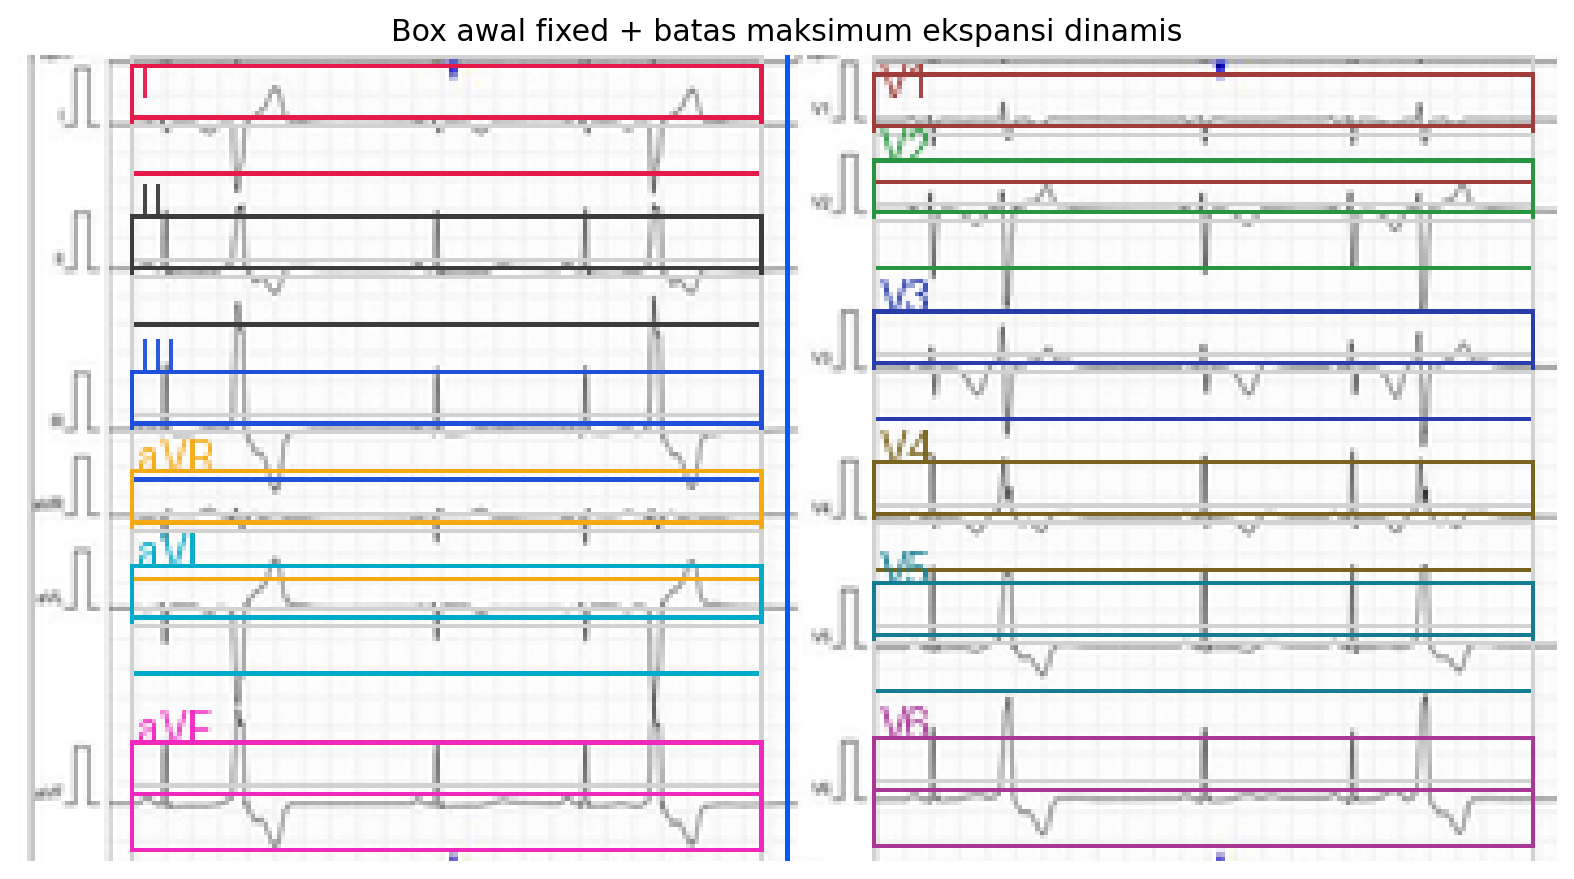

PosixPath('/home/nugee/code-program/code-thesis/thesis-severity/data/patient/valid/P-00007/ecg/segmentation-validation/03_initial_fixed_lead_boxes.png')

In [623]:
def expansion_limits_for_row(row: dict, side_rows: list[dict], image_height: int) -> tuple[int, int]:
    """Limit lebih longgar dari band awal, tetapi tetap dijaga dari baseline lead tetangga."""
    index = int(row["lead_index"]) - 1
    baseline_y = int(row["baseline_y"])
    band_y0 = int(row["band_y0"])
    band_y1 = int(row["band_y1"])

    limit_y0 = max(0, band_y0 - MAX_VERTICAL_EXTRA)
    limit_y1 = min(image_height, band_y1 + MAX_VERTICAL_EXTRA)

    if index > 0:
        prev_baseline = int(side_rows[index - 1]["baseline_y"])
        limit_y0 = max(limit_y0, prev_baseline + NEIGHBOR_BASELINE_GUARD)
    if index < len(side_rows) - 1:
        next_baseline = int(side_rows[index + 1]["baseline_y"])
        limit_y1 = min(limit_y1, next_baseline - NEIGHBOR_BASELINE_GUARD)

    limit_y0 = min(limit_y0, baseline_y - 1)
    limit_y1 = max(limit_y1, baseline_y + 1)
    return limit_y0, limit_y1


def initial_lead_boxes(baselines: list[dict]) -> list[dict]:
    width, height = crop_image.size
    split_x = width // 2
    side_lookup = {
        side: sorted([row for row in baselines if row["side"] == side], key=lambda item: int(item["lead_index"]))
        for side in ("left", "right")
    }

    boxes = []
    for row in baselines:
        if row["side"] == "left":
            x0 = LEFT_SIGNAL_MARGIN
            x1 = split_x - EDGE_MARGIN
        else:
            x0 = split_x + RIGHT_SIGNAL_MARGIN
            x1 = width - EDGE_MARGIN

        limit_y0, limit_y1 = expansion_limits_for_row(row, side_lookup[row["side"]], height)
        baseline_y = int(row["baseline_y"])
        y0 = max(limit_y0, baseline_y - INITIAL_LEAD_HALF_HEIGHT)
        y1 = min(limit_y1, baseline_y + INITIAL_LEAD_HALF_HEIGHT + 1)
        if y1 - y0 < MIN_LEAD_HEIGHT:
            target = min(MIN_LEAD_HEIGHT, limit_y1 - limit_y0)
            y0 = max(limit_y0, baseline_y - target // 2)
            y1 = min(limit_y1, y0 + target)
            y0 = max(limit_y0, y1 - target)

        boxes.append({
            **row,
            "x0": x0,
            "y0": y0,
            "x1": x1,
            "y1": y1,
            "limit_y0": limit_y0,
            "limit_y1": limit_y1,
        })
    return boxes


def visualize_initial_boxes(boxes: list[dict]) -> Path:
    image = crop_image.copy()
    draw = ImageDraw.Draw(image)
    width, height = image.size
    draw.line((width // 2, 0, width // 2, height), fill=(0, 90, 255), width=1)

    for box in boxes:
        color = LEAD_COLORS[box["lead_label"]]
        # Garis tipis lebih luar adalah batas maksimum ekspansi atas/bawah.
        draw.rectangle((box["x0"], box["limit_y0"], box["x1"], box["limit_y1"]), outline=(210, 210, 210), width=1)
        draw.rectangle((box["x0"], box["y0"], box["x1"], box["y1"]), outline=color, width=1)
        draw.line((box["x0"], box["baseline_y"], box["x1"], box["baseline_y"]), fill=color, width=1)
        draw.text((box["x0"] + 2, max(0, box["y0"] - 9)), box["lead_label"], fill=color)

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.imshow(image)
    ax.set_title("Box awal fixed + batas maksimum ekspansi dinamis")
    ax.axis("off")
    fig.tight_layout()
    return save_fig(fig, "03_initial_fixed_lead_boxes.png")


initial_boxes = initial_lead_boxes(baselines)
visualize_initial_boxes(initial_boxes)


## 6. Otsu dan satu sinyal utama sebagai mask

Mask dibuat langsung dari hasil Otsu. Bridge kecil hanya dipakai untuk memilih kelompok sinyal utama yang memanjang kiri-kanan dan dekat baseline; mask final memakai main signal tersebut tanpa thinning atau erosi agar bentuk sinyal tidak berubah lagi.


In [624]:
def apply_otsu_blur(gray: np.ndarray) -> np.ndarray:
    kernel_w, kernel_h = OTSU_BLUR_KERNEL
    if kernel_w <= 1 or kernel_h <= 1:
        return gray.copy()
    return cv2.GaussianBlur(gray, OTSU_BLUR_KERNEL, 0)


def preprocess_lead_mask(lead_image: Image.Image, baseline_local_y: int) -> dict:
    rgb = np.array(lead_image.convert("RGB"))
    gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
    blur = apply_otsu_blur(gray)
    otsu_threshold, raw_otsu = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    signal_threshold = int(np.clip(
        otsu_threshold - OTSU_SIGNAL_OFFSET,
        SIGNAL_THRESHOLD_MIN,
        SIGNAL_THRESHOLD_MAX,
    ))
    otsu = np.where(blur < signal_threshold, 255, 0).astype(np.uint8)

    main_signal_mask, main_component_info = keep_single_main_signal_component(otsu, baseline_local_y)
    return {
        "gray": gray,
        "blur": blur,
        "raw_otsu": raw_otsu,
        "otsu": otsu,
        "connected_mask": main_signal_mask,
        "mask": main_signal_mask,
        "line_mask": main_signal_mask,
        "touch_mask": main_signal_mask,
        "signal_threshold": signal_threshold,
        "main_component_info": main_component_info,
        "mask_source": "main_signal_without_thinning",
    }


def keep_single_main_signal_component(mask: np.ndarray, baseline_local_y: int) -> tuple[np.ndarray, dict]:
    binary = (mask > 0).astype(np.uint8)
    if binary.max() == 0:
        return np.zeros_like(binary, dtype=np.uint8), {"reason": "empty_otsu"}

    # Bridge hanya untuk grouping/seleksi komponen utama. Mask final tetap memakai pixel Otsu asli.
    bridge_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, MAIN_SIGNAL_BRIDGE_KERNEL)
    bridge_mask = cv2.dilate(binary, bridge_kernel, iterations=1)
    component_id, labels, stats, component_info = choose_main_component(bridge_mask, baseline_local_y)
    if component_id is None:
        return np.zeros_like(binary, dtype=np.uint8), {"reason": "no_component"}

    selected_otsu = np.where((labels == component_id) & (binary > 0), 255, 0).astype(np.uint8)
    selected_otsu = remove_tiny_components(selected_otsu)
    repaired = repair_main_signal_gaps(selected_otsu)
    repaired_summary = connected_component_summary(repaired)

    component_info.update({
        "reason": "selected_otsu_main_signal",
        "otsu_components_before_repair": int(connected_component_summary(selected_otsu)["count"]),
        "otsu_components_after_repair": int(repaired_summary["count"]),
        "repair_used": bool(repaired_summary["count"] == 1 and connected_component_summary(selected_otsu)["count"] != 1),
    })
    return repaired, component_info


def choose_main_component(mask: np.ndarray, baseline_local_y: int):
    binary = (mask > 0).astype(np.uint8)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
    if num_labels <= 1:
        return None, labels, stats, {"reason": "no_foreground"}

    image_height, image_width = binary.shape
    baseline_top = baseline_local_y - BASELINE_NEAR_MARGIN
    baseline_bottom = baseline_local_y + BASELINE_NEAR_MARGIN
    min_span = image_width * MAIN_SIGNAL_MIN_SPAN_RATIO

    best_id = None
    best_score = -1e18
    best_info = {}
    fallback_id = None
    fallback_score = -1e18
    fallback_info = {}

    for component_id in range(1, num_labels):
        x, y, width, height, area = stats[component_id]
        if area < CONNECTED_MIN_AREA:
            continue

        component_top = y
        component_bottom = y + height - 1
        intersects_baseline = component_top <= baseline_bottom and component_bottom >= baseline_top
        if component_bottom < baseline_top:
            baseline_distance = baseline_top - component_bottom
        elif component_top > baseline_bottom:
            baseline_distance = component_top - baseline_bottom
        else:
            baseline_distance = 0

        touches_left = x <= MAIN_SIGNAL_EDGE_MARGIN
        touches_right = (x + width) >= (image_width - MAIN_SIGNAL_EDGE_MARGIN)
        span_ratio = width / max(1, image_width)
        baseline_bonus = 200 if intersects_baseline else max(0, 80 - baseline_distance * 8)
        edge_bonus = (60 if touches_left else 0) + (60 if touches_right else 0)
        score = width * 4.0 + area * 0.04 + baseline_bonus + edge_bonus - baseline_distance * 10.0

        info = {
            "component_id": int(component_id),
            "x": int(x),
            "y": int(y),
            "width": int(width),
            "height": int(height),
            "area": int(area),
            "span_ratio": float(span_ratio),
            "baseline_distance": int(baseline_distance),
            "touches_left": bool(touches_left),
            "touches_right": bool(touches_right),
            "intersects_baseline": bool(intersects_baseline),
            "score": float(score),
        }

        if score > fallback_score:
            fallback_id = component_id
            fallback_score = score
            fallback_info = info

        if width >= min_span and baseline_distance <= COMPONENT_MAX_GAP_TO_BASELINE:
            if score > best_score:
                best_id = component_id
                best_score = score
                best_info = info

    if best_id is not None:
        return best_id, labels, stats, best_info
    return fallback_id, labels, stats, fallback_info


def remove_tiny_components(mask: np.ndarray) -> np.ndarray:
    binary = (mask > 0).astype(np.uint8)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
    if num_labels <= 1:
        return (binary * 255).astype(np.uint8)

    keep = np.zeros_like(binary, dtype=np.uint8)
    for component_id in range(1, num_labels):
        x, y, width, height, area = stats[component_id]
        if area >= CONNECTED_MIN_AREA and width >= CONNECTED_MIN_WIDTH and height >= CONNECTED_MIN_HEIGHT:
            keep[labels == component_id] = 1
    return (keep * 255).astype(np.uint8)


def keep_largest_component(mask: np.ndarray) -> np.ndarray:
    binary = (mask > 0).astype(np.uint8)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
    if num_labels <= 1:
        return (binary * 255).astype(np.uint8)

    best_id = max(range(1, num_labels), key=lambda component_id: stats[component_id, cv2.CC_STAT_AREA])
    return np.where(labels == best_id, 255, 0).astype(np.uint8)


def connected_component_summary(mask: np.ndarray) -> dict:
    binary = (mask > 0).astype(np.uint8)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
    components = []
    for component_id in range(1, num_labels):
        x, y, width, height, area = stats[component_id]
        if area >= CONNECTED_MIN_AREA:
            components.append({
                "component_id": int(component_id),
                "x": int(x),
                "y": int(y),
                "width": int(width),
                "height": int(height),
                "area": int(area),
            })
    if not components:
        return {"count": 0, "x_span": 0, "area": 0}
    largest = max(components, key=lambda item: item["area"])
    widest = max(components, key=lambda item: item["width"])
    return {
        "count": len(components),
        "x_span": widest["width"],
        "area": largest["area"],
        "largest": largest,
        "widest": widest,
    }


def repair_column_gaps(mask: np.ndarray) -> np.ndarray:
    result = (mask > 0).astype(np.uint8) * 255
    columns = np.flatnonzero(np.any(result > 0, axis=0))
    if len(columns) <= 1:
        return result.astype(np.uint8)

    for left_x, right_x in zip(columns[:-1], columns[1:]):
        gap = int(right_x - left_x)
        if gap <= 1 or gap > MAIN_SIGNAL_REPAIR_MAX_GAP:
            continue
        left_y = int(np.median(np.flatnonzero(result[:, left_x] > 0)))
        right_y = int(np.median(np.flatnonzero(result[:, right_x] > 0)))
        cv2.line(result, (int(left_x), left_y), (int(right_x), right_y), 255, thickness=1)
    return result.astype(np.uint8)


def component_edge_point(labels: np.ndarray, component_id: int, side: str) -> tuple[int, int]:
    ys, xs = np.where(labels == component_id)
    target_x = xs.min() if side == "left" else xs.max()
    candidate_ys = ys[xs == target_x]
    return int(target_x), int(np.median(candidate_ys))


def connect_components_by_x(mask: np.ndarray) -> np.ndarray:
    result = (mask > 0).astype(np.uint8) * 255
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats((result > 0).astype(np.uint8), connectivity=8)
    component_ids = [
        component_id
        for component_id in range(1, num_labels)
        if stats[component_id, cv2.CC_STAT_AREA] >= CONNECTED_MIN_AREA
    ]
    if len(component_ids) <= 1:
        return result.astype(np.uint8)

    component_ids.sort(key=lambda component_id: stats[component_id, cv2.CC_STAT_LEFT])
    for left_id, right_id in zip(component_ids[:-1], component_ids[1:]):
        x_left, y_left = component_edge_point(labels, left_id, side="right")
        x_right, y_right = component_edge_point(labels, right_id, side="left")
        if x_right <= x_left:
            continue
        cv2.line(result, (x_left, y_left), (x_right, y_right), 255, thickness=1)
    return result.astype(np.uint8)


def repair_main_signal_gaps(mask: np.ndarray) -> np.ndarray:
    if np.count_nonzero(mask) == 0:
        return mask.astype(np.uint8)

    repaired = repair_column_gaps(mask)
    if connected_component_summary(repaired)["count"] == 1:
        return repaired.astype(np.uint8)

    repaired = connect_components_by_x(repaired)
    summary = connected_component_summary(repaired)
    if summary["count"] == 1:
        return repaired.astype(np.uint8)

    # Fallback terakhir: ambil komponen dengan span horizontal terbesar, bukan area terbesar.
    binary = (repaired > 0).astype(np.uint8)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
    if num_labels <= 1:
        return (binary * 255).astype(np.uint8)
    widest_id = max(range(1, num_labels), key=lambda component_id: stats[component_id, cv2.CC_STAT_WIDTH])
    return np.where(labels == widest_id, 255, 0).astype(np.uint8)



def mask_touches_bounds(mask: np.ndarray) -> tuple[bool, bool]:
    if mask.size == 0 or np.count_nonzero(mask) == 0:
        return False, False
    top = bool(np.any(mask[:TOUCH_MARGIN + 1, :] > 0))
    bottom = bool(np.any(mask[-(TOUCH_MARGIN + 1):, :] > 0))
    return top, bottom


def expand_box_until_signal_inside(box: dict) -> dict:
    y0 = int(box["y0"])
    y1 = int(box["y1"])
    limit_y0 = int(box["limit_y0"])
    limit_y1 = int(box["limit_y1"])
    history = []
    stages = None

    for iteration in range(MAX_EXPAND_ITER + 1):
        lead_image = crop_image.crop((box["x0"], y0, box["x1"], y1))
        baseline_local_y = int(box["baseline_y"]) - y0
        stages = preprocess_lead_mask(lead_image, baseline_local_y)
        touch_top, touch_bottom = mask_touches_bounds(stages["touch_mask"])
        history.append({"iteration": iteration, "y0": y0, "y1": y1, "touch_top": touch_top, "touch_bottom": touch_bottom})

        expand_top = touch_top and y0 > limit_y0
        expand_bottom = touch_bottom and y1 < limit_y1
        if not expand_top and not expand_bottom:
            break

        new_y0 = max(limit_y0, y0 - EXPAND_STEP) if expand_top else y0
        new_y1 = min(limit_y1, y1 + EXPAND_STEP) if expand_bottom else y1
        if new_y0 == y0 and new_y1 == y1:
            break
        y0, y1 = new_y0, new_y1

    final_box = {
        **box,
        "y0": y0,
        "y1": y1,
        "height": y1 - y0,
        "iterations": len(history) - 1,
        "history": history,
        "stages": stages,
        "hit_top_limit": y0 <= limit_y0,
        "hit_bottom_limit": y1 >= limit_y1,
    }
    final_box["touch_top"], final_box["touch_bottom"] = mask_touches_bounds(stages["touch_mask"])
    return final_box


final_segments = [expand_box_until_signal_inside(box) for box in initial_boxes]
print("Segmentasi lead selesai: Otsu -> main signal sebagai mask utama.")


Segmentasi lead selesai: Otsu -> main signal sebagai mask utama.


## 7. Visual per lead: crop akhir, Otsu, main signal, dan mask


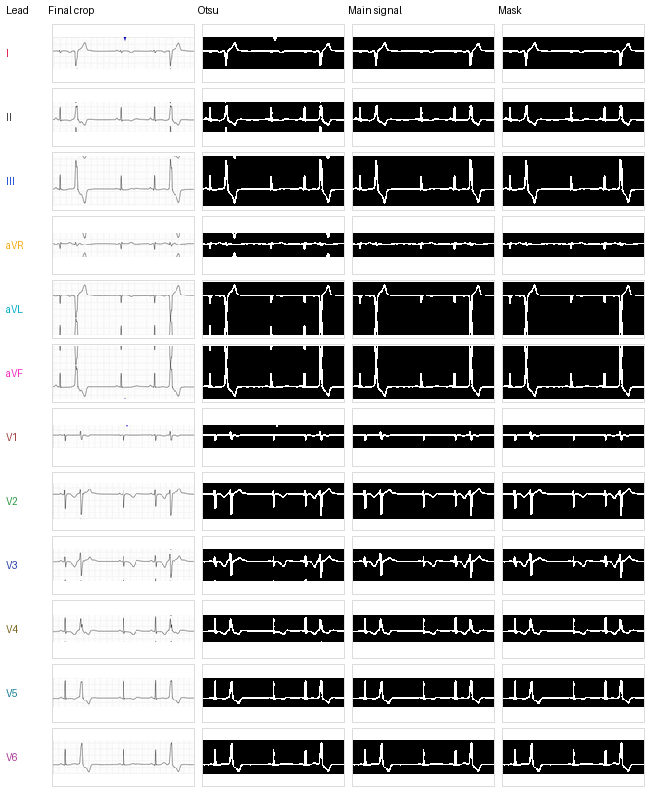

PosixPath('/home/nugee/code-program/code-thesis/thesis-severity/data/patient/valid/P-00007/ecg/segmentation-validation/04_lead_segmentation_stages.png')

In [625]:
def binary_to_rgb(mask: np.ndarray) -> Image.Image:
    return Image.fromarray(mask.astype(np.uint8)).convert("RGB")


def fit_image(image: Image.Image, size: tuple[int, int]) -> Image.Image:
    image = image.convert("RGB")
    canvas = Image.new("RGB", size, "white")
    scale = min(size[0] / image.width, size[1] / image.height)
    resized = image.resize((max(1, round(image.width * scale)), max(1, round(image.height * scale))), Image.Resampling.NEAREST)
    canvas.paste(resized, ((size[0] - resized.width) // 2, (size[1] - resized.height) // 2))
    return canvas


def visualize_lead_stage_grid(segments: list[dict]) -> Path:
    thumb_w, thumb_h = 150, 58
    label_w = 48
    header_h = 24
    row_gap = 6
    canvas_w = label_w + 4 * thumb_w
    canvas_h = header_h + len(segments) * (thumb_h + row_gap) + 8
    canvas = Image.new("RGB", (canvas_w, canvas_h), "white")
    draw = ImageDraw.Draw(canvas)

    headers = ["Lead", "Final crop", "Otsu", "Main signal", "Mask"]
    x_positions = [6, label_w, label_w + thumb_w, label_w + thumb_w * 2, label_w + thumb_w * 3]
    for x, header in zip(x_positions, headers):
        draw.text((x, 4), header, fill=(0, 0, 0))

    y = header_h
    for segment in segments:
        label = segment["lead_label"]
        color = LEAD_COLORS[label]
        lead_crop = crop_image.crop((segment["x0"], segment["y0"], segment["x1"], segment["y1"]))
        stages = segment["stages"]
        images = [
            lead_crop,
            binary_to_rgb(stages["otsu"]),
            binary_to_rgb(stages["connected_mask"]),
            binary_to_rgb(stages["line_mask"]),
        ]

        draw.text((6, y + thumb_h // 2 - 6), label, fill=color)
        for idx, image in enumerate(images):
            x = label_w + idx * thumb_w
            canvas.paste(fit_image(image, (thumb_w - 8, thumb_h)), (x + 4, y))
            draw.rectangle((x + 4, y, x + thumb_w - 4, y + thumb_h), outline=(220, 220, 220), width=1)
        y += thumb_h + row_gap

    output_path = OUTPUT_DIR / "04_lead_segmentation_stages.png"
    canvas.save(output_path)
    display(Image.open(output_path))
    return output_path


visualize_lead_stage_grid(final_segments)


## 8. Visual box akhir dan mask sinyal pada gambar crop

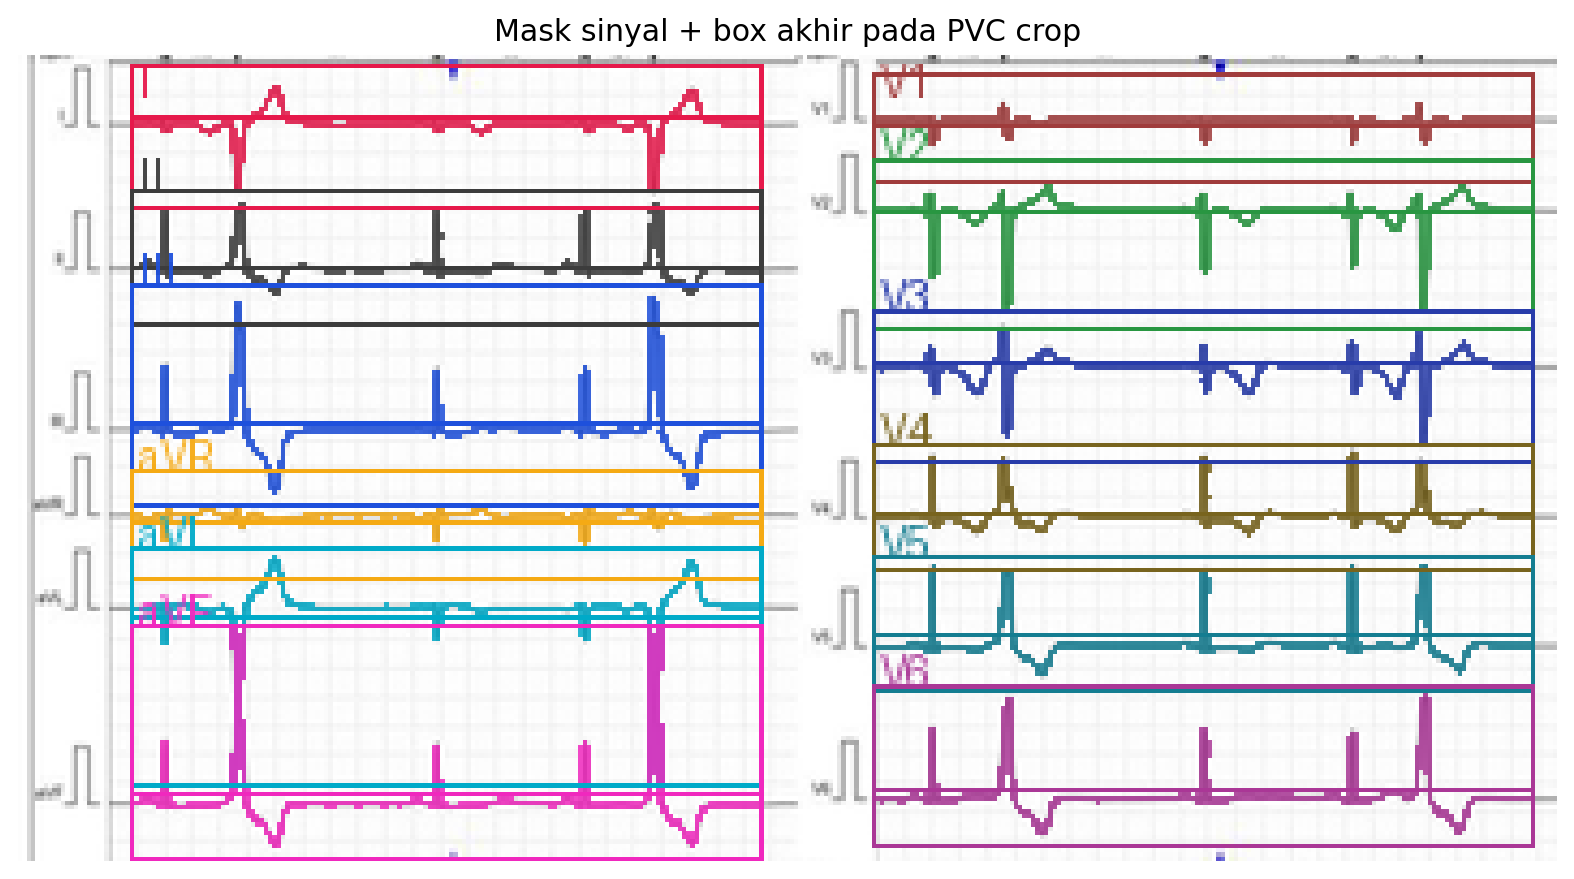

PosixPath('/home/nugee/code-program/code-thesis/thesis-severity/data/patient/valid/P-00007/ecg/segmentation-validation/05_final_mask_on_pvc_crop.png')

In [626]:
def overlay_mask_on_array(base: np.ndarray, mask: np.ndarray, x0: int, y0: int, color: tuple[int, int, int], alpha: float = 0.85) -> None:
    ys, xs = np.where(mask > 0)
    if len(ys) == 0:
        return
    yy = y0 + ys
    xx = x0 + xs
    valid = (yy >= 0) & (yy < base.shape[0]) & (xx >= 0) & (xx < base.shape[1])
    yy = yy[valid]
    xx = xx[valid]
    color_arr = np.array(color, dtype=np.float32)
    base[yy, xx] = (base[yy, xx].astype(np.float32) * (1 - alpha) + color_arr * alpha).astype(np.uint8)


def visualize_final_boxes_and_masks_on_crop(segments: list[dict]) -> Path:
    overlay = np.array(crop_image.convert("RGB"))
    for segment in segments:
        overlay_mask_on_array(
            overlay,
            segment["stages"]["line_mask"],
            int(segment["x0"]),
            int(segment["y0"]),
            LEAD_COLORS[segment["lead_label"]],
        )

    image = Image.fromarray(overlay)
    draw = ImageDraw.Draw(image)
    for segment in segments:
        color = LEAD_COLORS[segment["lead_label"]]
        draw.rectangle((segment["x0"], segment["y0"], segment["x1"], segment["y1"]), outline=color, width=1)
        draw.line((segment["x0"], segment["baseline_y"], segment["x1"], segment["baseline_y"]), fill=color, width=1)
        draw.text((segment["x0"] + 2, max(0, segment["y0"] - 9)), segment["lead_label"], fill=color)

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.imshow(image)
    ax.set_title("Mask sinyal + box akhir pada PVC crop")
    ax.axis("off")
    fig.tight_layout()
    return save_fig(fig, "05_final_mask_on_pvc_crop.png")


visualize_final_boxes_and_masks_on_crop(final_segments)

## 9. Tempel ulang mask sinyal ke ECG raw yang sudah di-resize

Koordinat mask dari gambar crop dikembalikan ke gambar ECG resized memakai offset crop box.

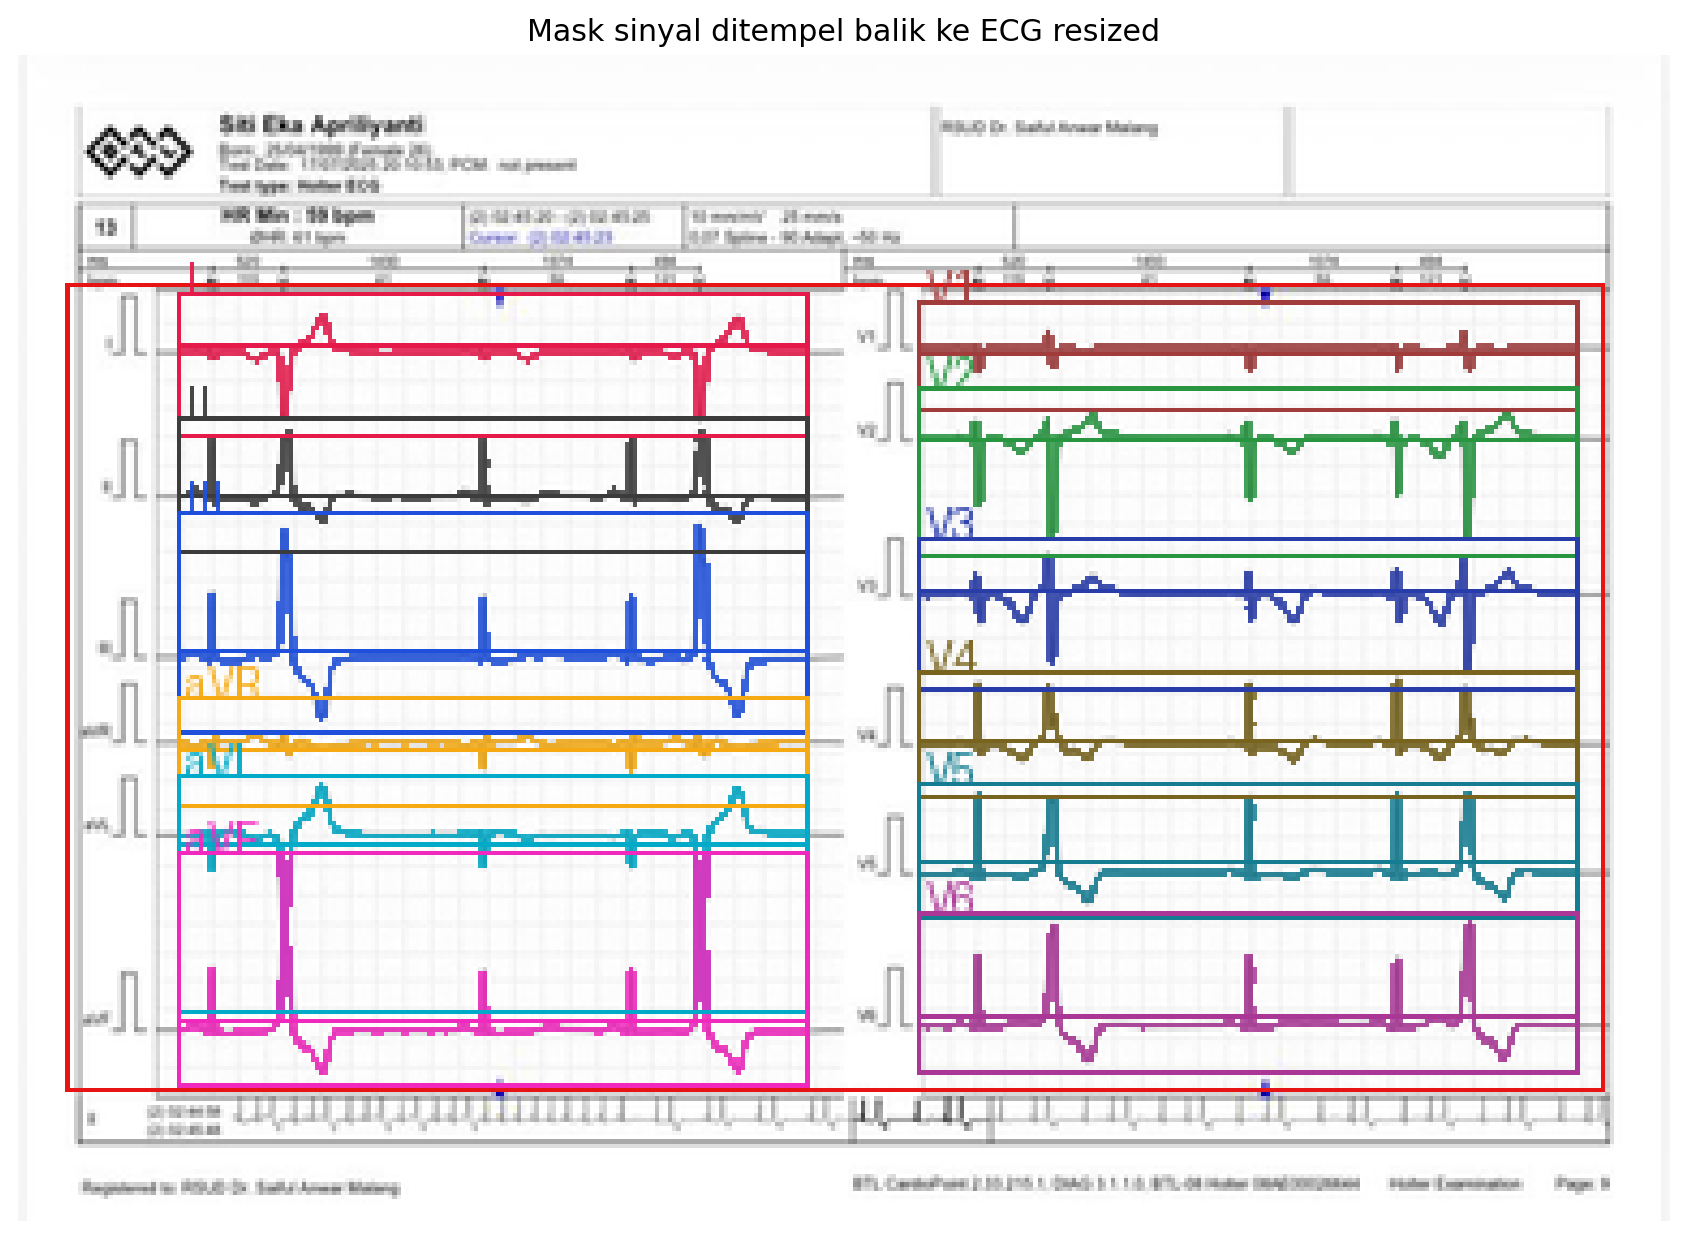

PosixPath('/home/nugee/code-program/code-thesis/thesis-severity/data/patient/valid/P-00007/ecg/segmentation-validation/06_signal_masks_on_resized_raw.png')

In [627]:
def visualize_masks_on_standardized_raw(segments: list[dict]) -> Path:
    overlay = np.array(standardized_image.convert("RGB"))
    offset_x = int(CROP_BOX["x1"])
    offset_y = int(CROP_BOX["y1"])

    for segment in segments:
        overlay_mask_on_array(
            overlay,
            segment["stages"]["line_mask"],
            offset_x + int(segment["x0"]),
            offset_y + int(segment["y0"]),
            LEAD_COLORS[segment["lead_label"]],
        )

    image = Image.fromarray(overlay)
    draw = ImageDraw.Draw(image)
    draw.rectangle((CROP_BOX["x1"], CROP_BOX["y1"], CROP_BOX["x2"], CROP_BOX["y2"]), outline=(230, 20, 20), width=1)

    for segment in segments:
        color = LEAD_COLORS[segment["lead_label"]]
        x0 = offset_x + int(segment["x0"])
        y0 = offset_y + int(segment["y0"])
        x1 = offset_x + int(segment["x1"])
        y1 = offset_y + int(segment["y1"])
        baseline = offset_y + int(segment["baseline_y"])
        draw.rectangle((x0, y0, x1, y1), outline=color, width=1)
        draw.line((x0, baseline, x1, baseline), fill=color, width=1)
        draw.text((x0 + 2, max(0, y0 - 9)), segment["lead_label"], fill=color)

    fig, ax = plt.subplots(figsize=(11, 7))
    ax.imshow(image)
    ax.set_title("Mask sinyal ditempel balik ke ECG resized")
    ax.axis("off")
    fig.tight_layout()
    return save_fig(fig, "06_signal_masks_on_resized_raw.png")


visualize_masks_on_standardized_raw(final_segments)

## 10. Visual per lead: crop, mask, dan overlay

Cell ini menampilkan hasil potongan setiap lead secara terpisah. Untuk tiap lead ditampilkan gambar crop akhir, mask hasil Otsu + connected component, dan overlay mask di atas crop asli.

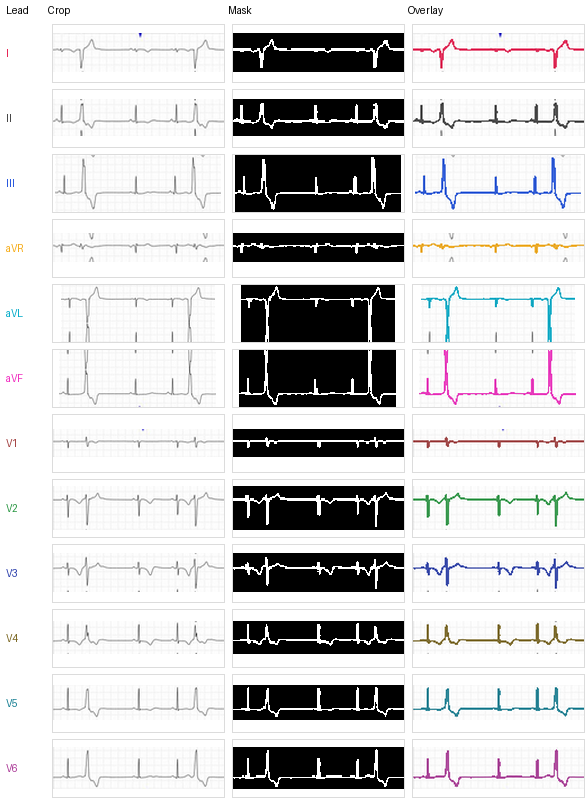

PosixPath('/home/nugee/code-program/code-thesis/thesis-severity/data/patient/valid/P-00007/ecg/segmentation-validation/07_each_lead_crop_mask_overlay.png')

In [628]:
def make_lead_mask_overlay(lead_crop: Image.Image, mask: np.ndarray, color: tuple[int, int, int], alpha: float = 0.85) -> Image.Image:
    overlay = np.array(lead_crop.convert("RGB"))
    ys, xs = np.where(mask > 0)
    if len(ys) > 0:
        color_arr = np.array(color, dtype=np.float32)
        overlay[ys, xs] = (overlay[ys, xs].astype(np.float32) * (1 - alpha) + color_arr * alpha).astype(np.uint8)
    return Image.fromarray(overlay)


def resize_for_panel(image: Image.Image, size: tuple[int, int], nearest: bool = False) -> Image.Image:
    image = image.convert("RGB")
    resample = Image.Resampling.NEAREST if nearest else Image.Resampling.LANCZOS
    scale = min(size[0] / image.width, size[1] / image.height)
    resized = image.resize((max(1, round(image.width * scale)), max(1, round(image.height * scale))), resample)
    canvas = Image.new("RGB", size, "white")
    canvas.paste(resized, ((size[0] - resized.width) // 2, (size[1] - resized.height) // 2))
    return canvas


def visualize_each_lead_crop_mask_overlay(segments: list[dict]) -> Path:
    panel_dir = OUTPUT_DIR / "lead-panels"
    overlay_dir = OUTPUT_DIR / "lead-overlays"
    panel_dir.mkdir(parents=True, exist_ok=True)
    overlay_dir.mkdir(parents=True, exist_ok=True)

    for old_path in list(panel_dir.glob("*.png")) + list(overlay_dir.glob("*.png")):
        old_path.unlink()

    cell_w = 180
    cell_h = 58
    label_w = 48
    header_h = 24
    row_gap = 7
    columns = ["Lead", "Crop", "Mask", "Overlay"]
    canvas_w = label_w + cell_w * 3
    canvas_h = header_h + len(segments) * (cell_h + row_gap) + 8
    canvas = Image.new("RGB", (canvas_w, canvas_h), "white")
    draw = ImageDraw.Draw(canvas)

    x_positions = [6, label_w, label_w + cell_w, label_w + cell_w * 2]
    for x, header in zip(x_positions, columns):
        draw.text((x, 4), header, fill=(0, 0, 0))

    y = header_h
    for order, segment in enumerate(segments, start=1):
        label = segment["lead_label"]
        color = LEAD_COLORS[label]
        lead_crop = crop_image.crop((segment["x0"], segment["y0"], segment["x1"], segment["y1"]))
        mask = segment["stages"]["line_mask"]
        mask_image = Image.fromarray(mask.astype(np.uint8)).convert("RGB")
        overlay = make_lead_mask_overlay(lead_crop, mask, color)

        safe_label = label.replace("/", "_")
        overlay.save(overlay_dir / f"{order:02d}_{safe_label}_overlay.png")

        panel = Image.new("RGB", (label_w + cell_w * 3, cell_h + header_h), "white")
        panel_draw = ImageDraw.Draw(panel)
        panel_draw.text((6, 4), label, fill=color)
        panel_draw.text((label_w, 4), "Crop", fill=(0, 0, 0))
        panel_draw.text((label_w + cell_w, 4), "Mask", fill=(0, 0, 0))
        panel_draw.text((label_w + cell_w * 2, 4), "Overlay", fill=(0, 0, 0))
        panel.paste(resize_for_panel(lead_crop, (cell_w - 8, cell_h), nearest=False), (label_w + 4, header_h))
        panel.paste(resize_for_panel(mask_image, (cell_w - 8, cell_h), nearest=True), (label_w + cell_w + 4, header_h))
        panel.paste(resize_for_panel(overlay, (cell_w - 8, cell_h), nearest=False), (label_w + cell_w * 2 + 4, header_h))
        panel.save(panel_dir / f"{order:02d}_{safe_label}_crop_mask_overlay.png")

        draw.text((6, y + cell_h // 2 - 6), label, fill=color)
        row_images = [
            resize_for_panel(lead_crop, (cell_w - 8, cell_h), nearest=False),
            resize_for_panel(mask_image, (cell_w - 8, cell_h), nearest=True),
            resize_for_panel(overlay, (cell_w - 8, cell_h), nearest=False),
        ]
        for idx, image in enumerate(row_images):
            x = label_w + idx * cell_w
            canvas.paste(image, (x + 4, y))
            draw.rectangle((x + 4, y, x + cell_w - 4, y + cell_h), outline=(220, 220, 220), width=1)
        y += cell_h + row_gap

    output_path = OUTPUT_DIR / "07_each_lead_crop_mask_overlay.png"
    canvas.save(output_path)
    display(Image.open(output_path))
    return output_path


visualize_each_lead_crop_mask_overlay(final_segments)

## 11. Rekonstruksi signal-only, deteksi R-peak, dan crop siklus

Setiap lead direkonstruksi menjadi gambar HD berbasis mask: area di luar mask dibuat putih, hanya sinyal utama yang dipertahankan. Dari rekonstruksi ini R-peak diberi titik merah, setiap peak diberi window kiri-kanan, lalu beat dipotong dan di-resize ke input YOLO 640x640.


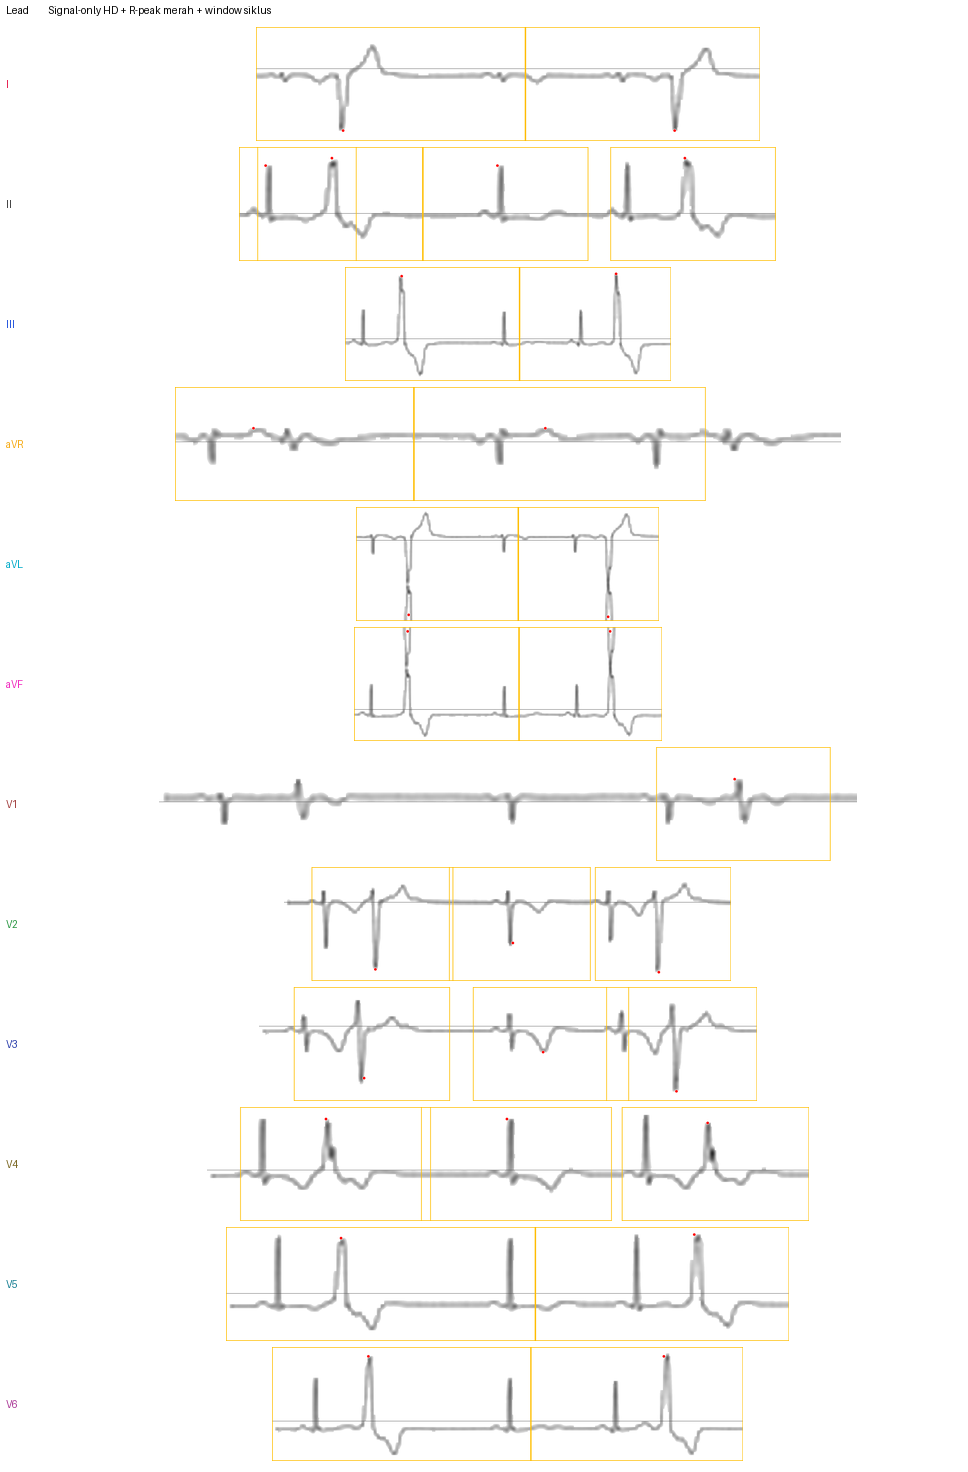

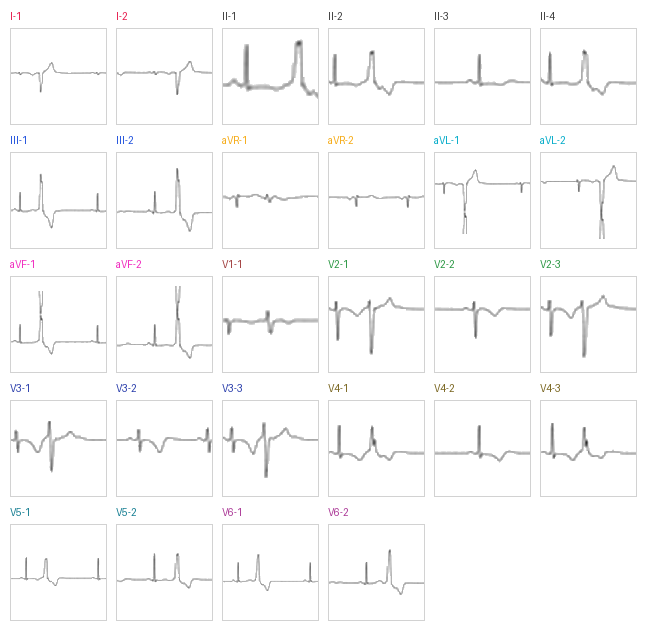

Cycle YOLO input tersimpan di: /home/nugee/code-program/code-thesis/thesis-severity/data/patient/valid/P-00007/ecg/segmentation-validation/cycle-yolo-inputs


In [629]:
def resize_mask_nearest(mask: np.ndarray, new_size: tuple[int, int]) -> np.ndarray:
    return cv2.resize(mask.astype(np.uint8), new_size, interpolation=cv2.INTER_NEAREST)


def make_signal_only_image(image: Image.Image, mask: np.ndarray) -> Image.Image:
    source = np.array(image.convert("RGB"))
    gray = cv2.cvtColor(source, cv2.COLOR_RGB2GRAY)
    mask_binary = (mask > 0).astype(np.uint8)
    if SIGNAL_ONLY_MASK_DILATE_KERNEL[0] > 1 or SIGNAL_ONLY_MASK_DILATE_KERNEL[1] > 1:
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, SIGNAL_ONLY_MASK_DILATE_KERNEL)
        mask_binary = cv2.dilate(mask_binary, kernel, iterations=1)

    signal_pixels = (mask_binary > 0) & (gray < SIGNAL_ONLY_DARK_THRESHOLD)
    signal_only = np.full_like(source, 255)
    signal_only[signal_pixels] = source[signal_pixels]

    # Bersihkan sisa background abu/grid yang ikut mask: pixel yang terlalu terang tetap putih.
    too_light = cv2.cvtColor(signal_only, cv2.COLOR_RGB2GRAY) >= SIGNAL_ONLY_DARK_THRESHOLD
    signal_only[too_light] = 255
    return Image.fromarray(signal_only)


def reconstruct_lead_to_height(segment: dict) -> dict:
    lead_crop = crop_image.crop((segment["x0"], segment["y0"], segment["x1"], segment["y1"]))
    mask = segment["stages"]["line_mask"]
    scale = RECONSTRUCTED_LEAD_HEIGHT / max(1, lead_crop.height)
    new_width = max(1, round(lead_crop.width * scale))
    new_size = (new_width, RECONSTRUCTED_LEAD_HEIGHT)
    reconstructed_crop = lead_crop.resize(new_size, Image.Resampling.LANCZOS)
    reconstructed_mask = resize_mask_nearest(mask, new_size)
    signal_only = make_signal_only_image(reconstructed_crop, reconstructed_mask)
    baseline_y = int(round((int(segment["baseline_y"]) - int(segment["y0"])) * scale))
    baseline_y = max(0, min(RECONSTRUCTED_LEAD_HEIGHT - 1, baseline_y))
    return {
        "crop": reconstructed_crop,
        "signal_only": signal_only,
        "mask": reconstructed_mask,
        "scale": scale,
        "baseline_y": baseline_y,
        "width": new_width,
        "height": RECONSTRUCTED_LEAD_HEIGHT,
    }


def moving_average(values: np.ndarray, kernel_size: int) -> np.ndarray:
    if kernel_size <= 1:
        return values.astype(float)
    kernel_size = kernel_size if kernel_size % 2 == 1 else kernel_size + 1
    kernel = np.ones(kernel_size, dtype=float) / kernel_size
    return np.convolve(values.astype(float), kernel, mode="same")


def signal_trace_from_mask(mask: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    height, width = mask.shape
    xs = []
    ys = []
    for x in range(width):
        y_positions = np.flatnonzero(mask[:, x] > 0)
        if len(y_positions) == 0:
            continue
        xs.append(x)
        ys.append(float(np.median(y_positions)))

    if len(xs) == 0:
        return np.arange(width), np.full(width, height / 2, dtype=float)

    xs = np.array(xs, dtype=int)
    ys = np.array(ys, dtype=float)
    full_x = np.arange(width)
    trace_y = np.interp(full_x, xs, ys)
    return full_x, trace_y


def non_max_suppress_peaks(candidates: list[tuple[int, float]], min_distance: int) -> list[int]:
    selected: list[tuple[int, float]] = []
    for x, score in sorted(candidates, key=lambda item: item[1], reverse=True):
        if all(abs(x - used_x) >= min_distance for used_x, _ in selected):
            selected.append((x, score))
    return sorted(x for x, _ in selected)


def detect_r_peaks_from_reconstruction(reconstructed: dict) -> dict:
    mask = reconstructed["mask"]
    baseline_y = reconstructed["baseline_y"]
    xs, trace_y = signal_trace_from_mask(mask)
    displacement = baseline_y - trace_y
    abs_displacement = np.abs(displacement)
    smooth_abs = moving_average(abs_displacement, RPEAK_SMOOTH_KERNEL)

    max_amp = float(smooth_abs.max()) if len(smooth_abs) else 0.0
    percentile_amp = float(np.percentile(smooth_abs, RPEAK_PERCENTILE_THRESHOLD)) if len(smooth_abs) else 0.0
    threshold = max(RPEAK_MIN_ABS_AMPLITUDE, percentile_amp, max_amp * RPEAK_RELATIVE_THRESHOLD)
    min_distance = max(1, int(mask.shape[1] * RPEAK_MIN_DISTANCE_RATIO))
    candidates = []
    for x in range(1, len(smooth_abs) - 1):
        if smooth_abs[x] >= threshold and smooth_abs[x] >= smooth_abs[x - 1] and smooth_abs[x] >= smooth_abs[x + 1]:
            candidates.append((x, float(smooth_abs[x])))

    peaks = non_max_suppress_peaks(candidates, min_distance=min_distance)
    peak_points = []
    for x in peaks[:MAX_CYCLES_PER_LEAD]:
        y_positions = np.flatnonzero(mask[:, x] > 0)
        if len(y_positions) > 0:
            # Pilih titik yang paling jauh dari baseline pada kolom peak.
            y = int(y_positions[np.argmax(np.abs(y_positions - baseline_y))])
        else:
            y = int(round(trace_y[x]))
        peak_points.append({"x": int(x), "y": y, "amplitude": float(abs_displacement[x])})

    return {
        "trace_x": xs,
        "trace_y": trace_y,
        "abs_displacement": abs_displacement,
        "smooth_abs_displacement": smooth_abs,
        "threshold": threshold,
        "min_distance": min_distance,
        "peaks": peak_points,
    }


def cycle_windows_from_peaks(peaks: list[dict], image_width: int) -> list[dict]:
    if not peaks:
        return []
    peak_xs = [int(item["x"]) for item in peaks]
    if len(peak_xs) >= 2:
        rr = int(np.median(np.diff(sorted(peak_xs))))
    else:
        rr = max(MIN_CYCLE_WIDTH, image_width // 4)
    left_width = max(MIN_CYCLE_WIDTH // 2, int(rr * CYCLE_LEFT_RR_RATIO))
    right_width = max(MIN_CYCLE_WIDTH // 2, int(rr * CYCLE_RIGHT_RR_RATIO))

    windows = []
    for order, peak in enumerate(peaks, start=1):
        peak_x = int(peak["x"])
        x0 = max(0, peak_x - left_width)
        x1 = min(image_width, peak_x + right_width)
        if x1 - x0 < MIN_CYCLE_WIDTH:
            shortage = MIN_CYCLE_WIDTH - (x1 - x0)
            x0 = max(0, x0 - shortage // 2)
            x1 = min(image_width, x1 + shortage - shortage // 2)
        windows.append({"order": order, "x0": int(x0), "x1": int(x1), "peak": peak})
    return windows


def yolo_letterbox_info(source_size: tuple[int, int]) -> dict:
    source_w, source_h = source_size
    scale = min(YOLO_INPUT_SIZE / max(1, source_w), YOLO_INPUT_SIZE / max(1, source_h))
    resized_w = max(1, round(source_w * scale))
    resized_h = max(1, round(source_h * scale))
    pad_x = (YOLO_INPUT_SIZE - resized_w) // 2
    pad_y = (YOLO_INPUT_SIZE - resized_h) // 2
    return {
        "scale": float(scale),
        "pad_x": int(pad_x),
        "pad_y": int(pad_y),
        "resized_width": int(resized_w),
        "resized_height": int(resized_h),
    }


def yolo_square_from_cycle(signal_only_image: Image.Image, x0: int, x1: int) -> Image.Image:
    cycle = signal_only_image.crop((x0, 0, x1, signal_only_image.height)).convert("RGB")
    canvas = Image.new("RGB", (YOLO_INPUT_SIZE, YOLO_INPUT_SIZE), "white")
    letterbox = yolo_letterbox_info(cycle.size)
    resized = cycle.resize((letterbox["resized_width"], letterbox["resized_height"]), Image.Resampling.LANCZOS)
    canvas.paste(resized, (letterbox["pad_x"], letterbox["pad_y"]))
    return canvas


def point_from_standard_to_raw(point: dict[str, int | float], raw_size: tuple[int, int]) -> dict[str, int]:
    raw_w, raw_h = raw_size
    scale_x = raw_w / STANDARD_SIZE[0]
    scale_y = raw_h / STANDARD_SIZE[1]
    return {
        "x": int(round(float(point["x"]) * scale_x)),
        "y": int(round(float(point["y"]) * scale_y)),
    }


def cycle_coordinate_metadata(record: dict, cycle: dict, lead_order: int) -> dict:
    segment = record["segment"]
    reconstructed = record["reconstructed"]
    scale = float(reconstructed["scale"])
    label = segment["lead_label"]
    cycle_x0_recon = int(cycle["x0"])
    cycle_x1_recon = int(cycle["x1"])
    peak = cycle["peak"]

    cycle_x0_lead = cycle_x0_recon / scale
    cycle_x1_lead = cycle_x1_recon / scale
    peak_x_lead = float(peak["x"]) / scale
    peak_y_lead = float(peak["y"]) / scale

    crop_box = {
        "x1": int(round(float(segment["x0"]) + cycle_x0_lead)),
        "y1": int(segment["y0"]),
        "x2": int(round(float(segment["x0"]) + cycle_x1_lead)),
        "y2": int(segment["y1"]),
    }
    standard_box = {
        "x1": int(CROP_BOX["x1"] + crop_box["x1"]),
        "y1": int(CROP_BOX["y1"] + crop_box["y1"]),
        "x2": int(CROP_BOX["x1"] + crop_box["x2"]),
        "y2": int(CROP_BOX["y1"] + crop_box["y2"]),
    }
    raw_box = box_from_standard_to_raw(standard_box, raw_image.size)

    peak_crop = {
        "x": int(round(float(segment["x0"]) + peak_x_lead)),
        "y": int(round(float(segment["y0"]) + peak_y_lead)),
    }
    peak_standard = {
        "x": int(CROP_BOX["x1"] + peak_crop["x"]),
        "y": int(CROP_BOX["y1"] + peak_crop["y"]),
    }
    peak_raw = point_from_standard_to_raw(peak_standard, raw_image.size)

    cycle_source_size = (cycle_x1_recon - cycle_x0_recon, RECONSTRUCTED_LEAD_HEIGHT)
    letterbox = yolo_letterbox_info(cycle_source_size)
    return {
        "cycle_id": f"{PATIENT_ID}_{lead_order:02d}_{label}_cycle_{cycle['order']:02d}",
        "patient_id": PATIENT_ID,
        "lead_order": int(lead_order),
        "lead_label": label,
        "cycle_order": int(cycle["order"]),
        "file_name": Path(cycle["path"]).name,
        "file_path": str(cycle["path"]),
        "sizes": {
            "raw_image": {"width": raw_image.width, "height": raw_image.height},
            "standardized_image": {"width": standardized_image.width, "height": standardized_image.height},
            "pvc_crop": {"width": crop_image.width, "height": crop_image.height},
            "lead_crop": {"width": int(segment["x1"] - segment["x0"]), "height": int(segment["y1"] - segment["y0"])},
            "reconstructed_lead": {"width": int(reconstructed["width"]), "height": int(reconstructed["height"])},
            "cycle_source": {"width": int(cycle_source_size[0]), "height": int(cycle_source_size[1])},
            "yolo_input": {"width": YOLO_INPUT_SIZE, "height": YOLO_INPUT_SIZE},
        },
        "reference_crop_box": reference_crop_box_for_patient(PATIENT_ID),
        "crop_box_standardized": {key: int(value) for key, value in CROP_BOX.items()},
        "crop_box_raw_image": active_crop_box_raw(),
        "lead_box_crop_coords": {"x1": int(segment["x0"]), "y1": int(segment["y0"]), "x2": int(segment["x1"]), "y2": int(segment["y1"])},
        "lead_box_standardized_coords": {
            "x1": int(CROP_BOX["x1"] + segment["x0"]),
            "y1": int(CROP_BOX["y1"] + segment["y0"]),
            "x2": int(CROP_BOX["x1"] + segment["x1"]),
            "y2": int(CROP_BOX["y1"] + segment["y1"]),
        },
        "cycle_window_reconstructed_coords": {"x1": cycle_x0_recon, "y1": 0, "x2": cycle_x1_recon, "y2": RECONSTRUCTED_LEAD_HEIGHT},
        "cycle_window_lead_crop_coords": {"x1": int(round(cycle_x0_lead)), "y1": 0, "x2": int(round(cycle_x1_lead)), "y2": int(segment["y1"] - segment["y0"])},
        "cycle_box_crop_coords": crop_box,
        "cycle_box_standardized_coords": standard_box,
        "cycle_box_raw_image_coords": raw_box,
        "r_peak": {
            "reconstructed_coords": {"x": int(peak["x"]), "y": int(peak["y"])},
            "lead_crop_coords": {"x": int(round(peak_x_lead)), "y": int(round(peak_y_lead))},
            "crop_coords": peak_crop,
            "standardized_coords": peak_standard,
            "raw_image_coords": peak_raw,
            "amplitude": float(peak.get("amplitude", 0.0)),
        },
        "yolo_letterbox": letterbox,
    }


def save_cycle_coordinate_metadata(records: list[dict]) -> Path:
    cycles = []
    for lead_order, record in enumerate(records, start=1):
        for cycle in record["cycles"]:
            cycles.append(cycle_coordinate_metadata(record, cycle, lead_order))

    metadata = {
        "patient_id": PATIENT_ID,
        "raw_ecg_path": str(raw_ecg_path(PATIENT_ID)),
        "raw_size": {"width": raw_image.width, "height": raw_image.height},
        "reference_size": {"width": REFERENCE_SIZE[0], "height": REFERENCE_SIZE[1]},
        "standardized_size": {"width": STANDARD_SIZE[0], "height": STANDARD_SIZE[1]},
        "reference_crop_box": reference_crop_box_for_patient(PATIENT_ID),
        "crop_box_standardized": {key: int(value) for key, value in CROP_BOX.items()},
        "crop_box_raw_image": active_crop_box_raw(),
        "pvc_crop_size": {"width": crop_image.width, "height": crop_image.height},
        "reconstructed_lead_height": RECONSTRUCTED_LEAD_HEIGHT,
        "yolo_input_size": YOLO_INPUT_SIZE,
        "cycle_count": len(cycles),
        "cycles": cycles,
    }
    output_path = OUTPUT_DIR / "cycle_coordinate_metadata.json"
    output_path.write_text(json.dumps(metadata, indent=2))
    return output_path


def build_rpeak_cycle_records(segments: list[dict]) -> list[dict]:
    records = []
    cycle_dir = OUTPUT_DIR / "cycle-yolo-inputs"
    cycle_dir.mkdir(parents=True, exist_ok=True)
    for old_path in cycle_dir.glob("*.png"):
        old_path.unlink()

    for lead_order, segment in enumerate(segments, start=1):
        reconstructed = reconstruct_lead_to_height(segment)
        detection = detect_r_peaks_from_reconstruction(reconstructed)
        windows = cycle_windows_from_peaks(detection["peaks"], reconstructed["width"])
        cycles = []
        safe_label = segment["lead_label"].replace("/", "_")
        for window in windows:
            yolo_image = yolo_square_from_cycle(reconstructed["signal_only"], window["x0"], window["x1"])
            filename = f"{lead_order:02d}_{safe_label}_cycle_{window['order']:02d}.png"
            yolo_image.save(cycle_dir / filename)
            cycles.append({**window, "yolo_image": yolo_image, "path": cycle_dir / filename})
        records.append({
            "segment": segment,
            "reconstructed": reconstructed,
            "detection": detection,
            "cycles": cycles,
        })
    save_cycle_coordinate_metadata(records)
    return records


def draw_rpeak_overlay(record: dict) -> Image.Image:
    segment = record["segment"]
    reconstructed = record["reconstructed"]
    detection = record["detection"]
    color = LEAD_COLORS[segment["lead_label"]]
    image = reconstructed["signal_only"].copy()
    draw = ImageDraw.Draw(image)
    baseline_y = reconstructed["baseline_y"]
    draw.line((0, baseline_y, reconstructed["width"], baseline_y), fill=(80, 80, 80), width=2)
    for cycle in record["cycles"]:
        draw.rectangle((cycle["x0"], 0, cycle["x1"], RECONSTRUCTED_LEAD_HEIGHT - 1), outline=(255, 190, 0), width=4)
    for peak in detection["peaks"]:
        x, y = int(peak["x"]), int(peak["y"])
        radius = 9
        draw.ellipse((x - radius, y - radius, x + radius, y + radius), fill=(255, 0, 0), outline=(255, 255, 255), width=2)
    return image


def fit_panel_image(image: Image.Image, size: tuple[int, int], nearest: bool = False) -> Image.Image:
    image = image.convert("RGB")
    resample = Image.Resampling.NEAREST if nearest else Image.Resampling.LANCZOS
    scale = min(size[0] / image.width, size[1] / image.height)
    resized = image.resize((max(1, round(image.width * scale)), max(1, round(image.height * scale))), resample)
    canvas = Image.new("RGB", size, "white")
    canvas.paste(resized, ((size[0] - resized.width) // 2, (size[1] - resized.height) // 2))
    return canvas


def visualize_reconstructed_rpeaks(records: list[dict]) -> Path:
    row_w, row_h = 920, 120
    label_w = 48
    header_h = 24
    canvas = Image.new("RGB", (label_w + row_w, header_h + len(records) * row_h + 8), "white")
    draw = ImageDraw.Draw(canvas)
    draw.text((6, 4), "Lead", fill=(0, 0, 0))
    draw.text((label_w, 4), "Signal-only HD + R-peak merah + window siklus", fill=(0, 0, 0))
    y = header_h
    for record in records:
        label = record["segment"]["lead_label"]
        color = LEAD_COLORS[label]
        overlay = draw_rpeak_overlay(record)
        canvas.paste(fit_panel_image(overlay, (row_w - 8, row_h - 6), nearest=False), (label_w + 4, y + 3))
        draw.text((6, y + row_h // 2 - 6), label, fill=color)
        y += row_h
    output_path = OUTPUT_DIR / "08_reconstructed_640_rpeak_windows.png"
    canvas.save(output_path)
    display(Image.open(output_path))
    return output_path


def visualize_cycle_crops(records: list[dict]) -> Path:
    cycle_items = []
    for record in records:
        label = record["segment"]["lead_label"]
        for cycle in record["cycles"]:
            cycle_items.append((label, cycle))
    if not cycle_items:
        output_path = OUTPUT_DIR / "09_cycle_crops_yolo_input.png"
        Image.new("RGB", (420, 80), "white").save(output_path)
        display(Image.open(output_path))
        return output_path

    thumb = 96
    label_h = 18
    gap = 10
    cols = 6
    rows = int(np.ceil(len(cycle_items) / cols))
    canvas = Image.new("RGB", (cols * (thumb + gap) + gap, rows * (thumb + label_h + gap) + gap), "white")
    draw = ImageDraw.Draw(canvas)
    for idx, (label, cycle) in enumerate(cycle_items):
        row = idx // cols
        col = idx % cols
        x = gap + col * (thumb + gap)
        y = gap + row * (thumb + label_h + gap)
        draw.text((x, y), f"{label}-{cycle['order']}", fill=LEAD_COLORS[label])
        canvas.paste(cycle["yolo_image"].resize((thumb, thumb), Image.Resampling.NEAREST), (x, y + label_h))
        draw.rectangle((x, y + label_h, x + thumb, y + label_h + thumb), outline=(210, 210, 210), width=1)
    output_path = OUTPUT_DIR / "09_cycle_crops_yolo_input.png"
    canvas.save(output_path)
    display(Image.open(output_path))
    return output_path


rpeak_cycle_records = build_rpeak_cycle_records(final_segments)
visualize_reconstructed_rpeaks(rpeak_cycle_records)
visualize_cycle_crops(rpeak_cycle_records)
print(f"Cycle YOLO input tersimpan di: {OUTPUT_DIR / 'cycle-yolo-inputs'}")


## 12. Simpan crop lead dan mask untuk validasi manual

Cell ini hanya menyimpan file gambar per lead, tanpa menampilkan tabel. Output berada di folder `segmentation-validation/lead-crops` dan `segmentation-validation/lead-masks`.

In [630]:
def save_lead_outputs(segments: list[dict]) -> None:
    crop_dir = OUTPUT_DIR / "lead-crops"
    mask_dir = OUTPUT_DIR / "lead-masks"
    crop_dir.mkdir(parents=True, exist_ok=True)
    mask_dir.mkdir(parents=True, exist_ok=True)

    for old_path in list(crop_dir.glob("*.png")) + list(mask_dir.glob("*.png")):
        old_path.unlink()

    for order, segment in enumerate(segments, start=1):
        label = segment["lead_label"].replace("/", "_")
        lead_crop = crop_image.crop((segment["x0"], segment["y0"], segment["x1"], segment["y1"]))
        lead_crop.save(crop_dir / f"{order:02d}_{label}.png")
        Image.fromarray(segment["stages"]["line_mask"].astype(np.uint8)).save(mask_dir / f"{order:02d}_{label}_mask.png")

    print(f"Output visual dan lead tersimpan di: {OUTPUT_DIR}")


save_lead_outputs(final_segments)

Output visual dan lead tersimpan di: /home/nugee/code-program/code-thesis/thesis-severity/data/patient/valid/P-00007/ecg/segmentation-validation


## 13. Batch preprocessing semua pasien valid

Cell paling bawah ini menjalankan preprocessing untuk semua folder pasien valid `P-*` di `data/patient/valid`. Output setiap pasien disimpan di folder `ecg/segmentation-validation/` masing-masing tanpa menampilkan semua visual satu per satu di notebook.


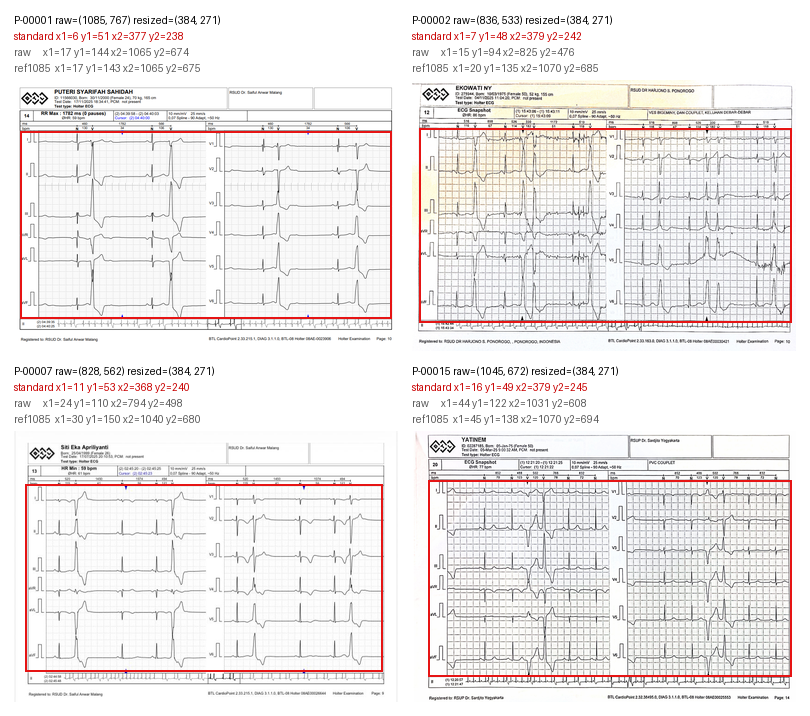

Crop box per pasien untuk adjustment:
P-00001: standard={'x1': 6, 'y1': 51, 'x2': 377, 'y2': 238}; raw={'x1': 17, 'y1': 144, 'x2': 1065, 'y2': 674}; ref1085={'x1': 17, 'y1': 143, 'x2': 1065, 'y2': 675}
P-00002: standard={'x1': 7, 'y1': 48, 'x2': 379, 'y2': 242}; raw={'x1': 15, 'y1': 94, 'x2': 825, 'y2': 476}; ref1085={'x1': 20, 'y1': 135, 'x2': 1070, 'y2': 685}
P-00007: standard={'x1': 11, 'y1': 53, 'x2': 368, 'y2': 240}; raw={'x1': 24, 'y1': 110, 'x2': 794, 'y2': 498}; ref1085={'x1': 30, 'y1': 150, 'x2': 1040, 'y2': 680}
P-00015: standard={'x1': 16, 'y1': 49, 'x2': 379, 'y2': 245}; raw={'x1': 44, 'y1': 122, 'x2': 1031, 'y2': 608}; ref1085={'x1': 45, 'y1': 138, 'x2': 1070, 'y2': 694}
Mulai batch preprocessing 4 pasien valid: P-00001, P-00002, P-00007, P-00015
Output visual dan lead tersimpan di: /home/nugee/code-program/code-thesis/thesis-severity/data/patient/valid/P-00001/ecg/segmentation-validation
OK P-00001: 12 lead, 24 cycle, output=/home/nugee/code-program/code-thesis/thesis-sev

In [631]:
def list_valid_patient_ids() -> list[str]:
    patient_dirs = [
        path for path in VALID_PATIENT_DIR.iterdir()
        if path.is_dir() and path.name.startswith("P-") and (path / "ecg").exists()
    ]
    return sorted(path.name for path in patient_dirs)


def preprocess_one_patient(patient_id: str, show_visual: bool = False) -> dict:
    global PATIENT_ID, OUTPUT_DIR, CROP_BOX, raw_image, standardized_image, crop_image
    global baselines, initial_boxes, final_segments, rpeak_cycle_records

    PATIENT_ID = patient_id
    OUTPUT_DIR = VALID_PATIENT_DIR / PATIENT_ID / "ecg" / "segmentation-validation"
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    CROP_BOX = crop_box_for_patient(PATIENT_ID)

    raw_image = load_raw_image(PATIENT_ID)
    standardized_image = standardize_image(raw_image)
    crop_image = crop_pvc_area(standardized_image)

    original_display = globals().get("display")
    if not show_visual:
        globals()["display"] = lambda *args, **kwargs: None

    try:
        baselines = estimate_12lead_baselines(crop_image)
        initial_boxes = initial_lead_boxes(baselines)
        final_segments = [expand_box_until_signal_inside(box) for box in initial_boxes]

        visualize_raw_crop()
        visualize_split_baseline(baselines)
        visualize_initial_boxes(initial_boxes)
        visualize_lead_stage_grid(final_segments)
        visualize_final_boxes_and_masks_on_crop(final_segments)
        visualize_masks_on_standardized_raw(final_segments)
        visualize_each_lead_crop_mask_overlay(final_segments)

        rpeak_cycle_records = build_rpeak_cycle_records(final_segments)
        visualize_reconstructed_rpeaks(rpeak_cycle_records)
        visualize_cycle_crops(rpeak_cycle_records)
        save_lead_outputs(final_segments)
    finally:
        if original_display is not None:
            globals()["display"] = original_display

    cycle_count = sum(len(record["cycles"]) for record in rpeak_cycle_records)
    return {
        "patient_id": PATIENT_ID,
        "raw_size": raw_image.size,
        "crop_size": crop_image.size,
        "crop_box_standardized": CROP_BOX,
        "crop_box_raw_image": active_crop_box_raw(),
        "lead_count": len(final_segments),
        "cycle_count": cycle_count,
        "output_dir": OUTPUT_DIR,
        "metadata_path": OUTPUT_DIR / "cycle_coordinate_metadata.json",
    }


def patient_crop_box_records(patient_ids: list[str] | None = None) -> list[dict]:
    patient_ids = patient_ids or list_valid_patient_ids()
    records = []
    for patient_id in patient_ids:
        image = load_raw_image(patient_id)
        standard_box = crop_box_for_patient(patient_id)
        records.append({
            "patient_id": patient_id,
            "raw_size": image.size,
            "standardized_size": STANDARD_SIZE,
            "reference_crop_box": reference_crop_box_for_patient(patient_id),
            "crop_box_standardized": standard_box,
            "crop_box_raw_image": box_from_standard_to_raw(standard_box, image.size),
        })
    return records


def visualize_patient_crop_boxes(patient_ids: list[str] | None = None) -> Path:
    records = patient_crop_box_records(patient_ids)
    thumb_w, thumb_h = 384, 271
    label_h = 66
    gap = 14
    cols = 2
    rows = int(np.ceil(len(records) / cols))
    canvas = Image.new("RGB", (cols * (thumb_w + gap) + gap, rows * (thumb_h + label_h + gap) + gap), "white")
    draw = ImageDraw.Draw(canvas)

    for idx, record in enumerate(records):
        row = idx // cols
        col = idx % cols
        x = gap + col * (thumb_w + gap)
        y = gap + row * (thumb_h + label_h + gap)
        patient_id = record["patient_id"]
        raw = load_raw_image(patient_id)
        resized = standardize_image(raw)
        box = record["crop_box_standardized"]
        preview = resized.copy()
        preview_draw = ImageDraw.Draw(preview)
        preview_draw.rectangle((box["x1"], box["y1"], box["x2"], box["y2"]), outline=(230, 20, 20), width=2)
        canvas.paste(preview, (x, y + label_h))
        draw.text((x, y), f"{patient_id} raw={record['raw_size']} resized={STANDARD_SIZE}", fill=(0, 0, 0))
        draw.text((x, y + 16), f"standard x1={box['x1']} y1={box['y1']} x2={box['x2']} y2={box['y2']}", fill=(200, 0, 0))
        raw_box = record["crop_box_raw_image"]
        draw.text((x, y + 32), f"raw      x1={raw_box['x1']} y1={raw_box['y1']} x2={raw_box['x2']} y2={raw_box['y2']}", fill=(90, 90, 90))
        ref_box = record["reference_crop_box"]
        draw.text((x, y + 48), f"ref1085  x1={ref_box['x1']} y1={ref_box['y1']} x2={ref_box['x2']} y2={ref_box['y2']}", fill=(90, 90, 90))

    output_path = VALID_PATIENT_DIR / "00_valid_patient_crop_box_preview.png"
    canvas.save(output_path)
    display(Image.open(output_path))

    print("Crop box per pasien untuk adjustment:")
    for record in records:
        b = record["crop_box_standardized"]
        rb = record["crop_box_raw_image"]
        ref = record["reference_crop_box"]
        print(
            f"{record['patient_id']}: "
            f"standard={{'x1': {b['x1']}, 'y1': {b['y1']}, 'x2': {b['x2']}, 'y2': {b['y2']}}}; "
            f"raw={{'x1': {rb['x1']}, 'y1': {rb['y1']}, 'x2': {rb['x2']}, 'y2': {rb['y2']}}}; "
            f"ref1085={{'x1': {ref['x1']}, 'y1': {ref['y1']}, 'x2': {ref['x2']}, 'y2': {ref['y2']}}}"
        )
    return output_path


def batch_preprocess_all_valid_patients(patient_ids: list[str] | None = None) -> list[dict]:
    patient_ids = patient_ids or list_valid_patient_ids()
    results = []
    print(f"Mulai batch preprocessing {len(patient_ids)} pasien valid: {', '.join(patient_ids)}")

    for patient_id in patient_ids:
        try:
            result = preprocess_one_patient(patient_id, show_visual=False)
            results.append(result)
            print(
                f"OK {patient_id}: {result['lead_count']} lead, "
                f"{result['cycle_count']} cycle, output={result['output_dir']}"
            )
        except Exception as error:
            results.append({"patient_id": patient_id, "error": str(error)})
            print(f"GAGAL {patient_id}: {error}")

    success_count = sum("error" not in result for result in results)
    print(f"Batch selesai: {success_count}/{len(results)} pasien berhasil diproses.")
    return results


crop_box_preview_path = visualize_patient_crop_boxes()
batch_results = batch_preprocess_all_valid_patients()
